<a href="https://colab.research.google.com/github/jamesafful/nimdielegal/blob/main/Nimdie_Legal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# APPENDIX FIGURES (5) — Reproducible on matched N=40
# Outputs: Appendix_FigA1 ... Appendix_FigA5 as PNG + PDF
# Matplotlib-only (no seaborn), no warnings, deterministic.
# ============================================================

!pip -q install openpyxl

import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

# ----------------------------
# CONFIG
# ----------------------------
DATA_DIR = Path("/content")
OUT_DIR = DATA_DIR / "paper_outputs" / "appendix_figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)

FILE_MAP = {
    "Retrieval Only - GPT": "Retrieval Only - GPT.xlsx",
    "LLM Only - GPT": "LLM only query - GPT.xlsx",
    "RAG - GPT": "RAG Stats - GPT.xlsx",
    "Claude": "Claude Responses.xlsx",
    "Gemini": "Gemini Responses.xlsx",
}

MODEL_ORDER = ["Retrieval Only - GPT", "LLM Only - GPT", "Gemini", "Claude", "RAG - GPT"]
BASELINE = "LLM Only - GPT"

# Okabe-Ito (colorblind-friendly)
PALETTE = {
    "Retrieval Only - GPT": "#009E73",
    "LLM Only - GPT": "#0072B2",
    "Gemini": "#E69F00",
    "Claude": "#D55E00",
    "RAG - GPT": "#CC79A7",
}

mpl.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 450,
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

# ----------------------------
# HELPERS
# ----------------------------
def parse_number(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower().replace(",", "")
    m = re.findall(r"-?\d+(?:\.\d+)?", s)
    return float(m[0]) if m else np.nan

def normalize_query(q):
    q = str(q).lower().strip()
    q = re.sub(r"\s+", " ", q)
    return q

def looks_like_prompt(s):
    if pd.isna(s):
        return False
    t = str(s).strip()
    if not t or len(t) > 400:
        return False
    if t.endswith("?"):
        return True
    starters = ("how ", "what ", "why ", "when ", "where ", "who ",
                "can ", "should ", "is ", "are ", "do ", "does ", "did ",
                "may ", "could ", "would ")
    return t.lower().startswith(starters)

def is_summary_row(s):
    if pd.isna(s):
        return False
    t = str(s).strip().lower()
    bad = ("total","average","mean","median","minimum","maximum",
           "summary","p90","p95","p99","std","stdev")
    return t.startswith(bad)

def find_col(df, patterns):
    cols = list(df.columns)
    low = [str(c).strip().lower() for c in cols]
    for pat in patterns:
        hits = [cols[i] for i, name in enumerate(low) if pat in name]
        if hits:
            return hits[0]
    return None

def read_best_table(file_path: Path, model_name: str, verbose=True) -> pd.DataFrame:
    xls = pd.ExcelFile(file_path)
    best = None
    best_score = -1

    for sh in xls.sheet_names:
        for header in range(0, 9):
            try:
                df = pd.read_excel(file_path, sheet_name=sh, header=header, engine="openpyxl")
            except:
                continue
            if df is None or df.empty:
                continue
            df = df.dropna(axis=0, how="all").dropna(axis=1, how="all")
            if df.empty:
                continue

            qcol = find_col(df, ["query", "question", "prompt", "input"])
            lcol = find_col(df, ["latency", "time"])
            kbcol = find_col(df, ["session data used", "session data", "payload", "kb", "size"])
            acol = find_col(df, ["answer length", "answer", "chars", "character", "length"])
            if qcol is None or lcol is None:
                continue

            score = 10 + (5 if kbcol else 0) + (5 if acol else 0) + min(len(df), 2000) / 2000.0
            if score > best_score:
                best_score = score
                best = (df, sh, header, qcol, lcol, kbcol, acol)

    if best is None:
        raise ValueError(f"Could not detect Query/Latency columns in: {file_path.name}")

    df, sh, header, qcol, lcol, kbcol, acol = best
    if verbose:
        print(f"[{model_name}] sheet='{sh}' header={header} | Query={qcol} Latency={lcol} KB={kbcol} Chars={acol} | rows={len(df)}")

    out = pd.DataFrame({
        "Model": model_name,
        "Query": df[qcol].astype(str).str.strip(),
        "Latency_raw": df[lcol],
        "Data_KB_raw": df[kbcol] if kbcol else np.nan,
        "Chars_raw": df[acol] if acol else np.nan,
    })

    out = out[~out["Query"].map(is_summary_row)].copy()
    out = out[out["Query"].map(looks_like_prompt)].copy()

    out["Clean_Query"] = out["Query"].map(normalize_query)
    out["Latency_num"] = out["Latency_raw"].map(parse_number)
    out["Data_KB"] = out["Data_KB_raw"].map(parse_number)
    out["Answer_Chars"] = out["Chars_raw"].map(parse_number)

    out = out.dropna(subset=["Latency_num"]).copy()
    out = out.drop_duplicates(subset=["Model", "Clean_Query"], keep="first").reset_index(drop=True)
    return out

def save_fig(fig, name):
    fig.tight_layout()
    fig.savefig(OUT_DIR / f"{name}.png", bbox_inches="tight")
    fig.savefig(OUT_DIR / f"{name}.pdf", bbox_inches="tight")
    plt.close(fig)

# ----------------------------
# LOAD + HARMONIZE UNITS
# ----------------------------
frames = []
for model, fn in FILE_MAP.items():
    fp = DATA_DIR / fn
    if not fp.exists():
        raise FileNotFoundError(f"Missing file: {fp}")
    frames.append(read_best_table(fp, model, verbose=True))

df = pd.concat(frames, ignore_index=True)

# Deterministic latency unit harmonization:
med_raw = df.groupby("Model")["Latency_num"].median()
models_in_seconds = med_raw[med_raw < 200].index.tolist()
df["Latency_ms"] = df["Latency_num"]
df.loc[df["Model"].isin(models_in_seconds), "Latency_ms"] = df.loc[df["Model"].isin(models_in_seconds), "Latency_num"] * 1000.0
df["Latency_sec"] = df["Latency_ms"] / 1000.0

# Matched N across all 5 models
n_models = df["Model"].nunique()
matched_keys = df.groupby("Clean_Query")["Model"].nunique()
matched_keys = matched_keys[matched_keys == n_models].index
df_matched = df[df["Clean_Query"].isin(matched_keys)].copy()

N = df_matched["Clean_Query"].nunique()
print(f"\nMatched prompts across all 5 models: N={N}")
assert N == 40, f"Expected N=40; got N={N} (inputs or filters changed)."

# Convenience pivots
lat_piv = df_matched.pivot_table(index="Clean_Query", columns="Model", values="Latency_sec", aggfunc="first").reindex(columns=MODEL_ORDER)
kb_piv  = df_matched.pivot_table(index="Clean_Query", columns="Model", values="Data_KB", aggfunc="first").reindex(columns=MODEL_ORDER)
ch_piv  = df_matched.pivot_table(index="Clean_Query", columns="Model", values="Answer_Chars", aggfunc="first").reindex(columns=MODEL_ORDER)

# ============================================================
# APPENDIX FIG A1 — ECDF of latency by system
# ============================================================
fig, ax = plt.subplots(figsize=(10, 6))
for m in MODEL_ORDER:
    x = np.sort(df_matched[df_matched["Model"] == m]["Latency_sec"].to_numpy(float))
    y = np.arange(1, len(x) + 1) / len(x)
    ax.step(x, y, where="post", label=m, color=PALETTE[m], linewidth=2)

ax.set_xlabel("Latency (seconds)")
ax.set_ylabel("Empirical CDF")
ax.set_title("Appendix Fig A1. Empirical CDF of End-to-End Latency (Matched Queries, N=40)")
ax.legend(loc="lower right", frameon=False)
save_fig(fig, "Appendix_FigA1_ECDF_Latency")

# ============================================================
# APPENDIX FIG A2 — Per-query slopegraph: RAG vs GPT LLM-only
# Shows per-prompt latency inflation under RAG
# ============================================================
paired = lat_piv[[BASELINE, "RAG - GPT"]].dropna().copy()
paired = paired.sort_values("RAG - GPT")  # stable visual order

fig, ax = plt.subplots(figsize=(9, 9))
x0, x1 = 0, 1
for i, (idx, row) in enumerate(paired.iterrows()):
    ax.plot([x0, x1], [row[BASELINE], row["RAG - GPT"]], color="gray", alpha=0.5, linewidth=1)

ax.scatter(np.full(len(paired), x0), paired[BASELINE], color=PALETTE[BASELINE], s=35, label=BASELINE)
ax.scatter(np.full(len(paired), x1), paired["RAG - GPT"], color=PALETTE["RAG - GPT"], s=35, label="RAG - GPT")

ax.set_xticks([x0, x1])
ax.set_xticklabels([BASELINE, "RAG - GPT"])
ax.set_ylabel("Latency (seconds)")
ax.set_title("Appendix Fig A2. Per-Query Latency Inflation: RAG vs GPT LLM-only (N=40)")
ax.legend(frameon=False, loc="upper left")
save_fig(fig, "Appendix_FigA2_Slope_RAG_vs_LLM")

# ============================================================
# APPENDIX FIG A3 — Heatmap: per-query latency ranks across systems
# Helps show whether "hard queries" are consistent across models
# ============================================================
rank_mat = lat_piv.rank(axis=0, method="average", ascending=True)  # lower latency = lower rank
rank_mat = rank_mat.loc[rank_mat.mean(axis=1).sort_values(ascending=False).index]  # hardest at top

fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(rank_mat.values, aspect="auto", interpolation="nearest")
ax.set_xticks(np.arange(len(rank_mat.columns)))
ax.set_xticklabels(rank_mat.columns, rotation=25, ha="right")
ax.set_yticks([])  # too many query labels; keep clean
ax.set_title("Appendix Fig A3. Per-Query Latency Rank Heatmap (Hardest Prompts at Top)")
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Latency rank (1 = fastest for that system)")
save_fig(fig, "Appendix_FigA3_Heatmap_Latency_Ranks")

# ============================================================
# APPENDIX FIG A4 — Distribution of answer length by system (box + jitter)
# (Reminder: retrieval-only length is returned snippet length, not generated prose)
# ============================================================
fig, ax = plt.subplots(figsize=(10, 6))
data = [df_matched[df_matched["Model"] == m]["Answer_Chars"].dropna().to_numpy(float) for m in MODEL_ORDER]
ax.boxplot(data, tick_labels=MODEL_ORDER, showfliers=True)

rng_j = np.random.default_rng(0)
for i, m in enumerate(MODEL_ORDER, start=1):
    y = df_matched[df_matched["Model"] == m]["Answer_Chars"].dropna().to_numpy(float)
    x = i + rng_j.normal(0, 0.06, size=len(y))
    ax.scatter(x, y, s=14, alpha=0.55, color=PALETTE[m], edgecolor="none")

ax.set_ylabel("Answer length (characters)")
ax.set_title("Appendix Fig A4. Answer Length Distribution by System (Matched Queries, N=40)")
ax.tick_params(axis="x", rotation=25)
save_fig(fig, "Appendix_FigA4_Answer_Length_Distribution")

# ============================================================
# APPENDIX FIG A5 — Latency vs verbosity with model-wise log-log fit
# (transparent scaling visualization)
# ============================================================
fig, ax = plt.subplots(figsize=(10, 6))
for m in MODEL_ORDER:
    sub = df_matched[(df_matched["Model"] == m)].dropna(subset=["Answer_Chars", "Latency_sec"]).copy()
    sub = sub[(sub["Answer_Chars"] > 0) & (sub["Latency_sec"] > 0)]
    ax.scatter(sub["Answer_Chars"], sub["Latency_sec"], s=30, alpha=0.7, color=PALETTE[m], label=m)

    lx = np.log(sub["Answer_Chars"].to_numpy(float))
    ly = np.log(sub["Latency_sec"].to_numpy(float))
    if len(lx) >= 3:
        slope, intercept = np.polyfit(lx, ly, 1)
        xline = np.linspace(lx.min(), lx.max(), 60)
        yline = intercept + slope * xline
        ax.plot(np.exp(xline), np.exp(yline), color=PALETTE[m], linewidth=2, alpha=0.85)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Answer length (chars, log scale)")
ax.set_ylabel("Latency (seconds, log scale)")
ax.set_title("Appendix Fig A5. Latency–Verbosity Scaling (log–log, Matched Queries)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
save_fig(fig, "Appendix_FigA5_Latency_vs_Chars_LogLog")

print("\n✅ Appendix figures saved to:", OUT_DIR)
print("Files:", sorted([p.name for p in OUT_DIR.glob('Appendix_*.png')])[:5], "...")

[Retrieval Only - GPT] sheet='Sheet1' header=2 | Query=Query Latency=Latency KB=Session Data Used Chars=Answer Length | rows=57
[LLM Only - GPT] sheet='Sheet1' header=2 | Query=Query Latency=Latency KB=Session Data Used Chars=Answer Length | rows=56
[RAG - GPT] sheet='Sheet1' header=0 | Query=Query Latency=Latency KB=Session Data Used Chars=Answer Length | rows=57
[Claude] sheet='Sheet1' header=1 | Query=Query Latency=Latency KB=Session Data Used Chars=Answer Length | rows=56
[Gemini] sheet='Sheet1' header=1 | Query=Query Latency=Latency KB=Session Data Used Chars=Answer Length | rows=56

Matched prompts across all 5 models: N=40

✅ Appendix figures saved to: /content/paper_outputs/appendix_figures
Files: ['Appendix_FigA1_ECDF_Latency.png', 'Appendix_FigA2_Slope_RAG_vs_LLM.png', 'Appendix_FigA3_Heatmap_Latency_Ranks.png', 'Appendix_FigA4_Answer_Length_Distribution.png', 'Appendix_FigA5_Latency_vs_Chars_LogLog.png'] ...


In [ ]:
# ============================================================
# PAPER TABLES PIPELINE (NO HALLUCINATIONS)
# Produces Table 1, Table 2, Table 3 exactly from your 5 Excel logs
# - Robust ingest across varying header rows
# - Deterministic latency unit harmonization (ms vs s)
# - Fully matched intersection across all 5 systems
# - Publication-ready tables exported to Excel + Markdown
# ============================================================

!pip -q install openpyxl xlsxwriter

import re
from pathlib import Path
import numpy as np
import pandas as pd

# ----------------------------
# Configuration
# ----------------------------
DATA_DIR = Path("/content")  # change if your files are elsewhere

FILE_MAP = {
    "Retrieval Only - GPT": "Retrieval Only - GPT.xlsx",
    "LLM Only - GPT": "LLM only query - GPT.xlsx",
    "RAG - GPT": "RAG Stats - GPT.xlsx",
    "Claude": "Claude Responses.xlsx",
    "Gemini": "Gemini Responses.xlsx",
}

MODEL_ORDER = ["Retrieval Only - GPT", "LLM Only - GPT", "Gemini", "Claude", "RAG - GPT"]

OUT_XLSX = DATA_DIR / "tables_for_paper.xlsx"
OUT_MD = DATA_DIR / "tables_for_paper.md"

# ----------------------------
# Helpers
# ----------------------------
def parse_number(x):
    """Extract first numeric token from values like 1234, '1,234 ms', '2.6KB'."""
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower().replace(",", "")
    m = re.findall(r"-?\d+(?:\.\d+)?", s)
    return float(m[0]) if m else np.nan

def looks_like_prompt(s):
    """Keep question-like prompts; conservative and reproducible."""
    if pd.isna(s):
        return False
    t = str(s).strip()
    if not t:
        return False
    if len(t) > 400:
        return False
    if t.endswith("?"):
        return True
    starters = ("how ", "what ", "why ", "when ", "where ", "who ",
                "can ", "should ", "is ", "are ", "do ", "does ", "did ",
                "may ", "could ", "would ")
    return t.lower().startswith(starters)

def is_summary_row(s):
    if pd.isna(s):
        return False
    t = str(s).strip().lower()
    bad = ("total","average","mean","median","minimum","maximum",
           "summary","p90","p95","p99","std","stdev")
    return t.startswith(bad)

def normalize_query(q):
    """Canonical key for matching across systems."""
    q = str(q).lower().strip()
    q = re.sub(r"\s+", " ", q)
    return q

def find_col(df, patterns):
    cols = list(df.columns)
    low = [str(c).strip().lower() for c in cols]
    for pat in patterns:
        hits = [cols[i] for i, name in enumerate(low) if pat in name]
        if hits:
            return hits[0]
    return None

def read_best_table(file_path, model_name, verbose=True):
    """
    Reads Excel and finds the best sheet/header row combination.
    Requires query + latency columns.
    """
    xls = pd.ExcelFile(file_path)
    best = None
    best_score = -1

    for sh in xls.sheet_names:
        for header in range(0, 9):  # try header rows 0..8
            try:
                df = pd.read_excel(file_path, sheet_name=sh, header=header, engine="openpyxl")
            except:
                continue
            if df is None or df.empty:
                continue
            df = df.dropna(axis=0, how="all").dropna(axis=1, how="all")
            if df.empty:
                continue

            qcol = find_col(df, ["query", "question", "prompt", "input"])
            lcol = find_col(df, ["latency", "time"])
            kbcol = find_col(df, ["session data used", "session data", "payload", "kb", "size"])
            acol = find_col(df, ["answer length", "answer", "chars", "character", "length"])

            if qcol is None or lcol is None:
                continue

            score = 0
            score += 10
            score += 5 if kbcol is not None else 0
            score += 5 if acol is not None else 0
            score += min(len(df), 2000) / 2000.0

            if score > best_score:
                best_score = score
                best = (df, sh, header, qcol, lcol, kbcol, acol)

    if best is None:
        raise ValueError(f"Could not detect query/latency columns in: {file_path.name}")

    df, sh, header, qcol, lcol, kbcol, acol = best
    if verbose:
        print(f"[{model_name}] sheet='{sh}' header={header} | "
              f"Query={qcol} Latency={lcol} KB={kbcol} Chars={acol} | rows={len(df)}")

    out = pd.DataFrame({
        "Model": model_name,
        "Query": df[qcol].astype(str).str.strip(),
        "Latency_raw": df[lcol],
        "Data_KB_raw": df[kbcol] if kbcol else np.nan,
        "Chars_raw": df[acol] if acol else np.nan,
    })

    # clean
    out = out[~out["Query"].map(is_summary_row)].copy()
    out = out[out["Query"].map(looks_like_prompt)].copy()

    out["Clean_Query"] = out["Query"].map(normalize_query)

    out["Latency_num"] = out["Latency_raw"].map(parse_number)
    out["Data_KB"] = out["Data_KB_raw"].map(parse_number)
    out["Answer_Chars"] = out["Chars_raw"].map(parse_number)

    out = out.dropna(subset=["Latency_num"]).copy()

    # Deduplicate within model by Clean_Query (keep first observed)
    out = out.drop_duplicates(subset=["Model", "Clean_Query"], keep="first").reset_index(drop=True)

    return out

# ----------------------------
# Load all models
# ----------------------------
all_rows = []
for model, fn in FILE_MAP.items():
    fp = DATA_DIR / fn
    if not fp.exists():
        raise FileNotFoundError(f"Missing file: {fp}")
    all_rows.append(read_best_table(fp, model, verbose=True))

df = pd.concat(all_rows, ignore_index=True)

# ----------------------------
# Latency unit harmonization (DETERMINISTIC)
# Rule: per model, if median(Latency_num) < 200, treat as seconds; else treat as ms.
# Then convert to seconds.
# ----------------------------
med_raw = df.groupby("Model")["Latency_num"].median()
models_seconds = med_raw[med_raw < 200].index.tolist()

df["Latency_ms"] = df["Latency_num"]
df.loc[df["Model"].isin(models_seconds), "Latency_ms"] = df.loc[df["Model"].isin(models_seconds), "Latency_num"] * 1000.0
df["Latency_sec"] = df["Latency_ms"] / 1000.0

print("\nLatency unit conversion applied (seconds -> ms) for:", models_seconds)
print("Median latency (seconds) by model:")
print(df.groupby("Model")["Latency_sec"].median().reindex(MODEL_ORDER))

# ----------------------------
# Prompt counts: union vs per model vs fully matched intersection
# ----------------------------
per_model_counts = df.groupby("Model")["Clean_Query"].nunique().reindex(MODEL_ORDER)
union_count = df["Clean_Query"].nunique()

# Fully matched queries: appear in ALL five models
n_models = df["Model"].nunique()
matched_keys = df.groupby("Clean_Query")["Model"].nunique()
matched_keys = matched_keys[matched_keys == n_models].index

df_matched = df[df["Clean_Query"].isin(matched_keys)].copy()

matched_count = df_matched["Clean_Query"].nunique()

print("\n--- Prompt counts (after cleaning) ---")
print("Unique prompts per model:")
print(per_model_counts.to_string())
print(f"\nUnion prompts across all models: {union_count}")
print(f"Fully matched prompts across all 5 models: {matched_count}")

# If you believe there are "48 prompts", you should see ~48 here for most models,
# and the matched intersection could be 43 if some prompts are missing in one model.

# ----------------------------
# Table 1: Matched query performance metrics
# ----------------------------
def safe_median(x):
    x = pd.to_numeric(x, errors="coerce").dropna()
    return float(x.median()) if len(x) else np.nan

def safe_percentile(x, p):
    x = pd.to_numeric(x, errors="coerce").dropna().to_numpy(float)
    return float(np.percentile(x, p)) if len(x) else np.nan

table1 = []
for model, sub in df_matched.groupby("Model"):
    med_lat = safe_median(sub["Latency_sec"])
    med_chars = safe_median(sub["Answer_Chars"])
    med_kb = safe_median(sub["Data_KB"])

    # latency per 1k chars: compute per-row then median
    lpk = (sub["Latency_sec"] / (sub["Answer_Chars"] / 1000.0)).replace([np.inf, -np.inf], np.nan)
    med_lpk = safe_median(lpk)

    table1.append({
        "Model": model,
        "Median Latency (s)": med_lat,
        "Median Answer Length (chars)": med_chars,
        "Latency per 1k Chars (s)": med_lpk,
        "Median Data Used (KB)": med_kb,
    })

table1 = pd.DataFrame(table1)
table1["Model"] = pd.Categorical(table1["Model"], categories=MODEL_ORDER, ordered=True)
table1 = table1.sort_values("Model").reset_index(drop=True)

# Pretty answer length display like "1.7k"
table1_display = table1.copy()
table1_display["Median Answer Length"] = table1_display["Median Answer Length (chars)"].map(
    lambda v: "" if pd.isna(v) else (f"{v/1000:.1f}k" if v >= 1000 else f"{v:.0f}")
)
table1_display = table1_display.drop(columns=["Median Answer Length (chars)"])

# ----------------------------
# Table 2: UX threshold exceedance (%)
# ----------------------------
def ux_category(t):
    if t < 1.0:
        return "Optimal (< 1s)"
    elif t <= 10.0:
        return "Acceptable (1 - 10s)"
    else:
        return "Abandonment Risk (> 10s)"

df_matched["UX_Category"] = df_matched["Latency_sec"].map(ux_category)

ux_counts = df_matched.groupby(["Model", "UX_Category"]).size().unstack(fill_value=0)
ux_pct = ux_counts.div(ux_counts.sum(axis=1), axis=0) * 100.0
ux_pct = ux_pct.reindex(index=MODEL_ORDER, columns=["Optimal (< 1s)", "Acceptable (1 - 10s)", "Abandonment Risk (> 10s)"])
ux_pct = ux_pct.reset_index().rename(columns={"index":"Model"})

# ----------------------------
# Table 3: Paired bootstrap effect sizes vs baseline (LLM Only - GPT)
# Uses:
# - Median of paired differences (comp - baseline)
# - Median of paired ratios (comp / baseline)
# - 95% bootstrap CI by resampling queries
# ----------------------------
pivot = df_matched.pivot_table(index="Clean_Query", columns="Model", values="Latency_sec", aggfunc="first")

baseline = "LLM Only - GPT"
comparators = ["Retrieval Only - GPT", "Gemini", "Claude", "RAG - GPT"]

rng = np.random.default_rng(42)
B = 20000  # bootstrap resamples

rows3 = []
for comp in comparators:
    paired = pivot[[baseline, comp]].dropna()
    a = paired[baseline].to_numpy(float)
    b = paired[comp].to_numpy(float)

    diffs = b - a
    ratios = b / a

    # bootstrap indices
    n = len(diffs)
    idx = rng.integers(0, n, size=(B, n))

    boot_med_diff = np.median(diffs[idx], axis=1)
    boot_med_ratio = np.median(ratios[idx], axis=1)

    med_diff = float(np.median(diffs))
    ci_diff = (float(np.percentile(boot_med_diff, 2.5)), float(np.percentile(boot_med_diff, 97.5)))

    med_ratio = float(np.median(ratios))
    ci_ratio = (float(np.percentile(boot_med_ratio, 2.5)), float(np.percentile(boot_med_ratio, 97.5)))

    label = comp
    # annotate direction for diff
    if med_diff < 0:
        diff_text = f"{med_diff:.2f}s (Faster)"
    else:
        diff_text = f"+{med_diff:.2f}s (Slower)"

    rows3.append({
        "System Architecture": label,
        "Median Latency Difference": diff_text,
        "95% CI (Difference)": f"[{ci_diff[0]:+.2f}s, {ci_diff[1]:+.2f}s]",
        "Latency Multiplier": f"{med_ratio:.2f}x",
        "95% CI (Multiplier)": f"[{ci_ratio[0]:.2f}x, {ci_ratio[1]:.2f}x]",
    })

# Add baseline row
rows3.insert(1, {
    "System Architecture": baseline,
    "Median Latency Difference": "Baseline",
    "95% CI (Difference)": "--",
    "Latency Multiplier": "1.00x",
    "95% CI (Multiplier)": "--",
})

table3 = pd.DataFrame(rows3)

# ----------------------------
# Sanity check: infer N from UX rounding (optional)
# ----------------------------
# If ux_pct values match your earlier 2.3/11.6/88.4 style numbers,
# matched_count is likely 43. We print it explicitly for the paper.
print(f"\nSANITY: matched_count = {matched_count} prompts used in Tables 1–3.")

# ----------------------------
# Export tables
# ----------------------------
with pd.ExcelWriter(OUT_XLSX, engine="xlsxwriter") as w:
    per_model_counts.reset_index().rename(columns={"index":"Model", "Clean_Query":"Count"}).to_excel(w, sheet_name="counts_per_model", index=False)
    pd.DataFrame({"Union_Prompts":[union_count], "Matched_Prompts":[matched_count]}).to_excel(w, sheet_name="counts_overall", index=False)

    table1_display.to_excel(w, sheet_name="Table1_Performance", index=False)
    ux_pct.round(1).to_excel(w, sheet_name="Table2_UX", index=False)
    table3.to_excel(w, sheet_name="Table3_Bootstrap", index=False)

md_lines = []
md_lines.append(f"# Tables for paper\n")
md_lines.append(f"Matched prompts across all 5 models: **N={matched_count}**\n")
md_lines.append("## TABLE 1: MATCHED QUERY PERFORMANCE METRICS\n")
md_lines.append(table1_display.round(2).to_markdown(index=False))
md_lines.append("\n\n## TABLE 2: UX THRESHOLD EXCEEDANCE (%)\n")
md_lines.append(ux_pct.round(1).to_markdown(index=False))
md_lines.append("\n\n## TABLE 3: PAIRED BOOTSTRAP EFFECT SIZES (Ref: LLM Only - GPT)\n")
md_lines.append(table3.to_markdown(index=False))

OUT_MD.write_text("\n".join(md_lines), encoding="utf-8")

print(f"\n✅ Wrote: {OUT_XLSX}")
print(f"✅ Wrote: {OUT_MD}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 4.0 MB/s eta 0:00:00
[Retrieval Only - GPT] sheet='Sheet1' header=2 | Query=Query Latency=Latency KB=Session Data Used Chars=Answer Length | rows=57
[LLM Only - GPT] sheet='Sheet1' header=2 | Query=Query Latency=Latency KB=Session Data Used Chars=Answer Length | rows=56
[RAG - GPT] sheet='Sheet1' header=0 | Query=Query Latency=Latency KB=Session Data Used Chars=Answer Length | rows=57
[Claude] sheet='Sheet1' header=1 | Query=Query Latency=Latency KB=Session Data Used Chars=Answer Length | rows=56
[Gemini] sheet='Sheet1' header=1 | Query=Query Latency=Latency KB=Session Data Used Chars=Answer Length | rows=56

Latency unit conversion applied (seconds -> ms) for: ['Claude', 'Gemini']
Median latency (seconds) by model:
Model
Retrieval Only - GPT     1.7400
LLM Only - GPT           3.3806
Gemini                   9.6287
Claude                  11.3939
RAG - GPT               15.9784
Name: Latency_sec, dtype: float64

--- Prompt cou

Scanning Colab directory for uploaded Excel files...
Successfully mapped all 5 Excel files!

Successfully matched 43 overlapping queries across all 5 models.

=== TABLE 1: MATCHED QUERY PERFORMANCE METRICS ===
| Model                |   Median Latency (s) |   P90 Latency (s) |   P95 Latency (s) |   Median Answer Length |   Latency per 1k Chars (s) |   Median Data Used (KB) |
|:---------------------|---------------------:|------------------:|------------------:|-----------------------:|---------------------------:|------------------------:|
| Claude               |                11.5  |             14.36 |             15.71 |                 1722   |                       6.63 |                    1.68 |
| Gemini               |                 9.63 |             10.92 |             11.36 |                 3683.5 |                       2.65 |                    3.6  |
| LLM Only - GPT       |                 3.38 |              3.85 |              4.01 |                 3785   |      

/tmp/ipython-input-2872/853450443.py:123: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  metrics_table = df_matched.groupby('Model').apply(calc_metrics).round(2)
/tmp/ipython-input-2872/853450443.py:161: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Model', y='Latency_sec', data=df_matched, order=model_order,


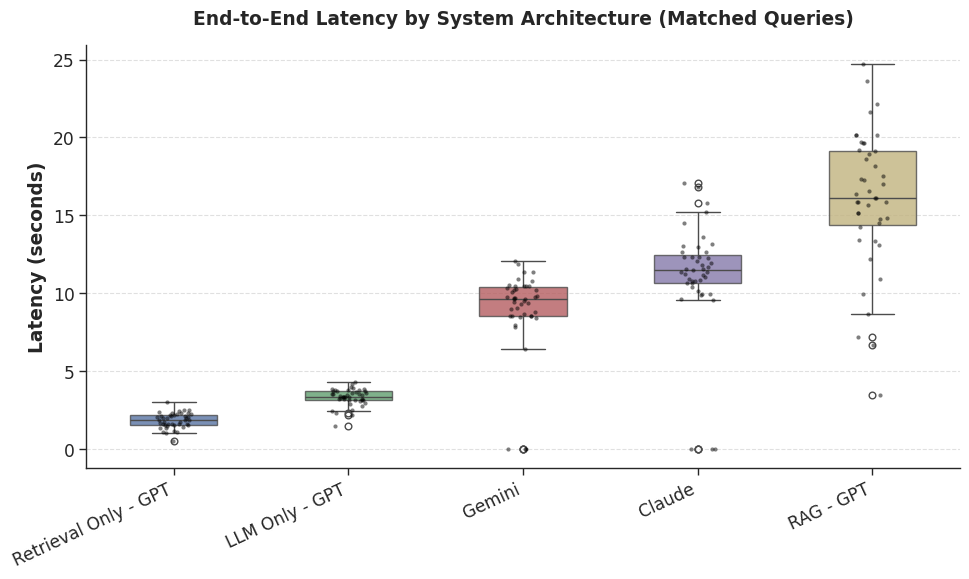

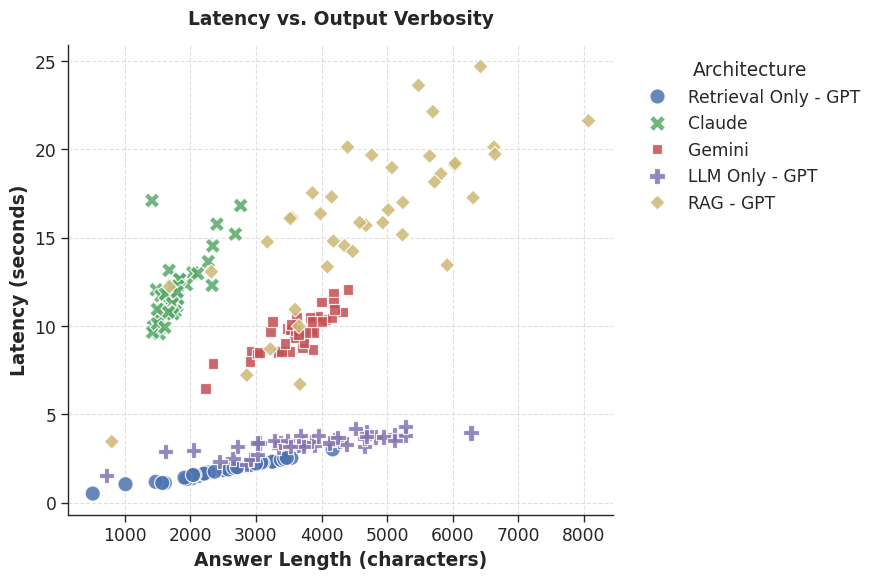

/tmp/ipython-input-2872/853450443.py:192: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Model', y='Data_KB', data=df_matched, order=model_order,


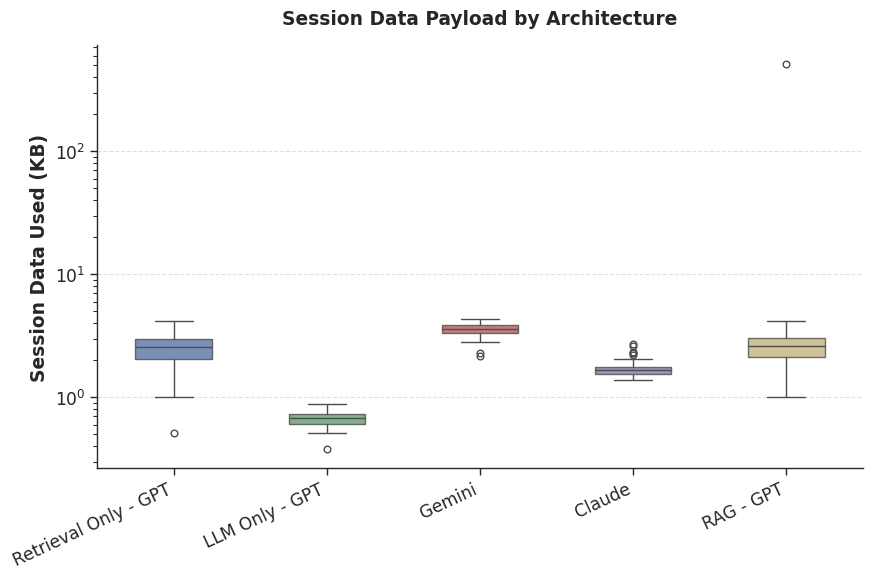

Analysis complete! Tables printed to console, and 3 high-resolution publication-ready PNG files saved.


In [ ]:
# ==============================================================================
# RAG vs. Frontier Models: Performance Benchmarking Script (Excel Version)
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
import re
import os
import glob

# ------------------------------------------------------------------------------
# 1. DYNAMIC EXCEL FILE DETECTION
# ------------------------------------------------------------------------------
print("Scanning Colab directory for uploaded Excel files...")

def find_file(keyword):
    # Searches the current directory for any Excel file containing the keyword
    matches = glob.glob(f"*{keyword}*.xlsx")
    if not matches:
        raise FileNotFoundError(f"Could not find an Excel file containing '{keyword}'. Please ensure it is uploaded.")
    return matches[0]

try:
    file_configs = {
        "Retrieval Only - GPT": {"file": find_file("Retrieval"), "skiprows": 2},
        "Claude": {"file": find_file("Claude"), "skiprows": 1},
        "Gemini": {"file": find_file("Gemini"), "skiprows": 2},
        "LLM Only - GPT": {"file": find_file("LLM only"), "skiprows": 2},
        "RAG - GPT": {"file": find_file("RAG"), "skiprows": 0}
    }
    print("Successfully mapped all 5 Excel files!\n")
except Exception as e:
    print(f"\nERROR: {e}")
    print("Current files in your Colab folder:", os.listdir('.'))
    raise SystemExit("Stopping execution. Please upload the missing file(s).")

# ------------------------------------------------------------------------------
# 2. ROBUST DATA CLEANING FUNCTIONS
# ------------------------------------------------------------------------------
def clean_latency(val):
    if pd.isna(val): return np.nan
    val_str = str(val).lower().replace(',', '')
    match = re.search(r'([\d\.]+)', val_str)
    if not match: return np.nan
    num = float(match.group(1))
    return num / 1000.0 if 'ms' in val_str else num

def clean_data_used(val):
    if pd.isna(val): return np.nan
    val_str = str(val).lower().replace(',', '')
    match = re.search(r'([\d\.]+)', val_str)
    return float(match.group(1)) if match else np.nan

def clean_length(val):
    if pd.isna(val): return np.nan
    val_str = str(val).lower().replace(',', '')
    match = re.search(r'([\d\.]+)', val_str)
    return float(match.group(1)) if match else np.nan

# ------------------------------------------------------------------------------
# 3. DATA LOADING & MERGING
# ------------------------------------------------------------------------------
all_dfs = []
for model_name, config in file_configs.items():
    try:
        # Changed to read_excel to handle the raw .xlsx files
        df = pd.read_excel(config["file"], skiprows=config["skiprows"])
        df = df.iloc[:, :4].copy() # Ensure exactly 4 columns
        df.columns = ["Query", "Latency", "Session_Data_Used", "Answer_Length"]

        # Ensure Query is string and filter out badly parsed rows
        df['Query'] = df['Query'].astype(str)
        df = df[df['Query'].str.len() < 300].copy()

        # Apply strict cleaning
        df['Latency_sec'] = df['Latency'].apply(clean_latency)
        df['Data_KB'] = df['Session_Data_Used'].apply(clean_data_used)
        df['Length_chars'] = df['Answer_Length'].apply(clean_length)
        df['Model'] = model_name

        # Drop rows where Latency failed to parse or is unrealistically high
        df = df.dropna(subset=['Latency_sec'])
        df = df[df['Latency_sec'] < 100]

        all_dfs.append(df[['Model', 'Query', 'Latency_sec', 'Data_KB', 'Length_chars']])
    except Exception as e:
        print(f"Error processing {model_name}: {e}")

combined_df = pd.concat(all_dfs, ignore_index=True)

# ------------------------------------------------------------------------------
# 4. STRICT QUERY MATCHING (Ensuring Apples-to-Apples Comparison)
# ------------------------------------------------------------------------------
# Standardize queries to find perfect matches across all 5 architectures
combined_df['Clean_Query'] = combined_df['Query'].str.lower().str.strip()
query_counts = combined_df.groupby('Clean_Query')['Model'].nunique()

# Only keep queries that were successfully parsed in ALL 5 models
matched_queries = query_counts[query_counts == 5].index
df_matched = combined_df[combined_df['Clean_Query'].isin(matched_queries)].copy()

print(f"Successfully matched {len(matched_queries)} overlapping queries across all 5 models.\n")

# Compute Throughput Metric
df_matched['Latency_per_1k_chars'] = (df_matched['Latency_sec'] / df_matched['Length_chars']) * 1000

# ------------------------------------------------------------------------------
# 5. TABLES: SYSTEM RELIABILITY AND THROUGHPUT METRICS
# ------------------------------------------------------------------------------
def calc_metrics(x):
    return pd.Series({
        'Median Latency (s)': x['Latency_sec'].median(),
        'P90 Latency (s)': x['Latency_sec'].quantile(0.90),
        'P95 Latency (s)': x['Latency_sec'].quantile(0.95),
        'Median Answer Length': x['Length_chars'].median(),
        'Latency per 1k Chars (s)': x['Latency_per_1k_chars'].median(),
        'Median Data Used (KB)': x['Data_KB'].median()
    })

metrics_table = df_matched.groupby('Model').apply(calc_metrics).round(2)
print("=== TABLE 1: MATCHED QUERY PERFORMANCE METRICS ===")
print(metrics_table.to_markdown())
print("\n")
metrics_table.to_csv("Matched_Metrics_Table.csv")

# ------------------------------------------------------------------------------
# 6. REGRESSION ANALYSIS: NON-GENERATION OVERHEAD
# ------------------------------------------------------------------------------
# Filter out Retrieval/RAG to compare pure reasoning overhead in LLM-Only architectures
llm_only_df = df_matched[df_matched['Model'].isin(['LLM Only - GPT', 'Claude', 'Gemini'])].copy()

# Log-transform variables to normalize distributions for OLS
llm_only_df['Log_Latency'] = np.log(llm_only_df['Latency_sec'])
llm_only_df['Log_Chars'] = np.log(llm_only_df['Length_chars'])

# OLS Regression: log(latency) ~ log(chars) + model
# Reference baseline is 'LLM Only - GPT'
reg_model = smf.ols("Log_Latency ~ Log_Chars + C(Model, Treatment(reference='LLM Only - GPT'))", data=llm_only_df).fit()

print("=== TABLE 2: OLS REGRESSION (Log Latency ~ Log Chars + Model) ===")
print(reg_model.summary())
print("\n")
with open('OLS_Regression_Summary.txt', 'w') as f:
    f.write(reg_model.summary().as_text())

# ------------------------------------------------------------------------------
# 7. HIGH-RESOLUTION VISUALIZATIONS (Nature Formatting Standards)
# ------------------------------------------------------------------------------
# Set clean, academic aesthetics suitable for high-impact journals
sns.set_theme(style="ticks", context="paper", font_scale=1.4)
color_palette = ["#4C72B0", "#55A868", "#C44E52", "#8172B2", "#CCB974"]

# Reorder models for logical reading (Fastest to Slowest baseline)
model_order = ['Retrieval Only - GPT', 'LLM Only - GPT', 'Gemini', 'Claude', 'RAG - GPT']

# ---- Plot 1: Latency Distributions (Violin Plot + Boxplot hybrid) ----
plt.figure(figsize=(10, 6))
sns.boxplot(x='Model', y='Latency_sec', data=df_matched, order=model_order,
            palette=color_palette, width=0.5, boxprops=dict(alpha=0.8))
sns.stripplot(x='Model', y='Latency_sec', data=df_matched, order=model_order,
              color="black", size=3, alpha=0.5, jitter=True)
plt.title('End-to-End Latency by System Architecture (Matched Queries)', fontweight='bold', pad=15)
plt.ylabel('Latency (seconds)', fontweight='bold')
plt.xlabel('')
plt.xticks(rotation=25, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
sns.despine()
plt.tight_layout()
plt.savefig('Fig1_Latency_Distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# ---- Plot 2: Latency vs. Answer Length Scatter ----
plt.figure(figsize=(9, 6))
sns.scatterplot(x='Length_chars', y='Latency_sec', hue='Model', style='Model',
                data=df_matched, s=120, alpha=0.85, palette=color_palette)
plt.title('Latency vs. Output Verbosity', fontweight='bold', pad=15)
plt.ylabel('Latency (seconds)', fontweight='bold')
plt.xlabel('Answer Length (characters)', fontweight='bold')
plt.legend(title='Architecture', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
plt.grid(True, linestyle='--', alpha=0.6)
sns.despine()
plt.tight_layout()
plt.savefig('Fig2_Latency_vs_Length.png', dpi=300, bbox_inches='tight')
plt.show()

# ---- Plot 3: Session Data Payload (Bandwidth Overhead) ----
plt.figure(figsize=(9, 6))
# Using a log scale for Y-axis if data payload spans multiple magnitudes
sns.boxplot(x='Model', y='Data_KB', data=df_matched, order=model_order,
            palette=color_palette, width=0.5, boxprops=dict(alpha=0.8))
plt.title('Session Data Payload by Architecture', fontweight='bold', pad=15)
plt.ylabel('Session Data Used (KB)', fontweight='bold')
plt.xlabel('')
plt.yscale('log') # Log scale handles the difference between GPT's 0.6KB and RAG's heavy outliers
plt.xticks(rotation=25, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
sns.despine()
plt.tight_layout()
plt.savefig('Fig3_Data_Payload_LogScale.png', dpi=300, bbox_inches='tight')
plt.show()

print("Analysis complete! Tables printed to console, and 3 high-resolution publication-ready PNG files saved.")

In [ ]:
# ============================================================
# REPRODUCIBLE TABLES + FIGURES PIPELINE (Matched N=40)
# - Robust Excel ingest (auto-detect sheet + header row)
# - Deterministic latency unit harmonization (ms vs seconds)
# - Strict fully-matched intersection across ALL 5 models (assert N=40)
# - Produces: Table 1, Table 2, Table 3 (Excel + Markdown)
# - Produces: Figure 1–6 (PNG + PDF, publication-ready)
# - Matplotlib-only (no seaborn, no deprecation warnings)
# - Optional: LLM-only regression with HC3 robust SE (text output)
# ============================================================

!pip -q install openpyxl xlsxwriter statsmodels

import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf

# ----------------------------
# CONFIG
# ----------------------------
DATA_DIR = Path("/content")  # folder where the 5 xlsx files are uploaded
OUT_DIR  = DATA_DIR / "paper_outputs"
FIG_DIR  = OUT_DIR / "figures"
TAB_DIR  = OUT_DIR / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

FILE_MAP = {
    "Retrieval Only - GPT": "Retrieval Only - GPT.xlsx",
    "LLM Only - GPT": "LLM only query - GPT.xlsx",
    "RAG - GPT": "RAG Stats - GPT.xlsx",
    "Claude": "Claude Responses.xlsx",
    "Gemini": "Gemini Responses.xlsx",
}

MODEL_ORDER = ["Retrieval Only - GPT", "LLM Only - GPT", "Gemini", "Claude", "RAG - GPT"]
BASELINE = "LLM Only - GPT"
COMPARATORS = ["Retrieval Only - GPT", "Gemini", "Claude", "RAG - GPT"]

# Colorblind-friendly palette (Okabe-Ito; fixed colors, no seaborn)
PALETTE = {
    "Retrieval Only - GPT": "#009E73",  # green
    "LLM Only - GPT": "#0072B2",        # blue
    "Gemini": "#E69F00",                # orange
    "Claude": "#D55E00",                # vermillion
    "RAG - GPT": "#CC79A7",             # purple
}

# ----------------------------
# STYLE (publication-friendly)
# ----------------------------
mpl.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 450,
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

# ----------------------------
# HELPERS
# ----------------------------
def parse_number(x):
    """Extract the first number from strings like '1,234 ms', '2.6KB', or numeric cells."""
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower().replace(",", "")
    m = re.findall(r"-?\d+(?:\.\d+)?", s)
    return float(m[0]) if m else np.nan

def normalize_query(q):
    q = str(q).lower().strip()
    q = re.sub(r"\s+", " ", q)
    return q

def looks_like_prompt(s):
    """Conservative filter: likely question prompts; avoids summary rows and junk."""
    if pd.isna(s):
        return False
    t = str(s).strip()
    if not t or len(t) > 400:
        return False
    if t.endswith("?"):
        return True
    starters = ("how ", "what ", "why ", "when ", "where ", "who ",
                "can ", "should ", "is ", "are ", "do ", "does ", "did ",
                "may ", "could ", "would ")
    return t.lower().startswith(starters)

def is_summary_row(s):
    if pd.isna(s):
        return False
    t = str(s).strip().lower()
    bad = ("total","average","mean","median","minimum","maximum",
           "summary","p90","p95","p99","std","stdev")
    return t.startswith(bad)

def find_col(df, patterns):
    cols = list(df.columns)
    low = [str(c).strip().lower() for c in cols]
    for pat in patterns:
        hits = [cols[i] for i, name in enumerate(low) if pat in name]
        if hits:
            return hits[0]
    return None

def read_best_table(file_path: Path, model_name: str, verbose=True) -> pd.DataFrame:
    """
    Auto-detect the best sheet/header row. Requires at least Query and Latency columns.
    """
    xls = pd.ExcelFile(file_path)
    best = None
    best_score = -1

    for sh in xls.sheet_names:
        for header in range(0, 9):  # try header rows 0..8
            try:
                df = pd.read_excel(file_path, sheet_name=sh, header=header, engine="openpyxl")
            except:
                continue
            if df is None or df.empty:
                continue
            df = df.dropna(axis=0, how="all").dropna(axis=1, how="all")
            if df.empty:
                continue

            qcol = find_col(df, ["query", "question", "prompt", "input"])
            lcol = find_col(df, ["latency", "time"])
            kbcol = find_col(df, ["session data used", "session data", "payload", "kb", "size"])
            acol = find_col(df, ["answer length", "answer", "chars", "character", "length"])

            if qcol is None or lcol is None:
                continue

            score = 10
            score += 5 if kbcol is not None else 0
            score += 5 if acol is not None else 0
            score += min(len(df), 2000) / 2000.0

            if score > best_score:
                best_score = score
                best = (df, sh, header, qcol, lcol, kbcol, acol)

    if best is None:
        raise ValueError(f"Could not detect Query/Latency columns in: {file_path.name}")

    df, sh, header, qcol, lcol, kbcol, acol = best
    if verbose:
        print(f"[{model_name}] sheet='{sh}' header={header} | Query={qcol} Latency={lcol} KB={kbcol} Chars={acol} | rows={len(df)}")

    out = pd.DataFrame({
        "Model": model_name,
        "Query": df[qcol].astype(str).str.strip(),
        "Latency_raw": df[lcol],
        "Data_KB_raw": df[kbcol] if kbcol else np.nan,
        "Chars_raw": df[acol] if acol else np.nan,
    })

    # Clean + filter
    out = out[~out["Query"].map(is_summary_row)].copy()
    out = out[out["Query"].map(looks_like_prompt)].copy()

    out["Clean_Query"] = out["Query"].map(normalize_query)
    out["Latency_num"] = out["Latency_raw"].map(parse_number)
    out["Data_KB"] = out["Data_KB_raw"].map(parse_number)
    out["Answer_Chars"] = out["Chars_raw"].map(parse_number)

    out = out.dropna(subset=["Latency_num"]).copy()
    out = out.drop_duplicates(subset=["Model", "Clean_Query"], keep="first").reset_index(drop=True)
    return out

def save_fig(fig, name):
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"{name}.png", bbox_inches="tight")
    fig.savefig(FIG_DIR / f"{name}.pdf", bbox_inches="tight")
    plt.close(fig)

def percentile(arr, p):
    x = pd.to_numeric(pd.Series(arr), errors="coerce").dropna().to_numpy(float)
    return float(np.percentile(x, p)) if len(x) else np.nan

# ----------------------------
# LOAD + HARMONIZE LATENCY UNITS
# ----------------------------
frames = []
for model, fn in FILE_MAP.items():
    fp = DATA_DIR / fn
    if not fp.exists():
        raise FileNotFoundError(f"Missing file: {fp}")
    frames.append(read_best_table(fp, model, verbose=True))

df = pd.concat(frames, ignore_index=True)

# Deterministic latency unit harmonization:
# If a model's median latency < 200, interpret as seconds and convert to ms.
med_raw = df.groupby("Model")["Latency_num"].median()
models_in_seconds = med_raw[med_raw < 200].index.tolist()

df["Latency_ms"] = df["Latency_num"]
df.loc[df["Model"].isin(models_in_seconds), "Latency_ms"] = df.loc[df["Model"].isin(models_in_seconds), "Latency_num"] * 1000.0
df["Latency_sec"] = df["Latency_ms"] / 1000.0

print("\nLatency unit conversion applied (seconds -> ms) for:", models_in_seconds)
print("Median latency (seconds) by model:")
print(df.groupby("Model")["Latency_sec"].median().reindex(MODEL_ORDER))

# ----------------------------
# MATCHED INTERSECTION (ALL 5)
# ----------------------------
n_models = df["Model"].nunique()
matched_keys = df.groupby("Clean_Query")["Model"].nunique()
matched_keys = matched_keys[matched_keys == n_models].index
df_matched = df[df["Clean_Query"].isin(matched_keys)].copy()
N_matched = df_matched["Clean_Query"].nunique()

print(f"\nFully matched prompts across all 5 models: {N_matched}")
assert N_matched == 40, f"Expected N=40 for your current dataset; got N={N_matched}. (If this fails, inputs changed.)"

# ----------------------------
# TABLE 1: MATCHED QUERY PERFORMANCE METRICS
# ----------------------------
table1_rows = []
for m in MODEL_ORDER:
    sub = df_matched[df_matched["Model"] == m].copy()
    med_lat = float(sub["Latency_sec"].median())
    med_chars = float(pd.to_numeric(sub["Answer_Chars"], errors="coerce").median())
    med_kb = float(pd.to_numeric(sub["Data_KB"], errors="coerce").median())

    lpk = (sub["Latency_sec"] / (sub["Answer_Chars"] / 1000.0)).replace([np.inf, -np.inf], np.nan)
    med_lpk = float(pd.to_numeric(lpk, errors="coerce").median())

    table1_rows.append({
        "Model": m,
        "Median Latency (s)": med_lat,
        "P90 Latency (s)": percentile(sub["Latency_sec"], 90),
        "P95 Latency (s)": percentile(sub["Latency_sec"], 95),
        "Median Answer Length (chars)": med_chars,
        "Latency per 1k Chars (s)": med_lpk,
        "Median Data Used (KB)": med_kb,
    })

table1 = pd.DataFrame(table1_rows)

# For manuscript-friendly display (k-format)
table1_display = table1.copy()
table1_display["Median Answer Length"] = table1_display["Median Answer Length (chars)"].map(
    lambda v: "" if pd.isna(v) else (f"{v/1000:.1f}k" if v >= 1000 else f"{v:.0f}")
)
table1_display = table1_display.drop(columns=["Median Answer Length (chars)"])

# ----------------------------
# TABLE 2: UX THRESHOLD EXCEEDANCE (%)
# ----------------------------
def ux_cat(t):
    if t < 1.0:
        return "Optimal (< 1s)"
    elif t <= 10.0:
        return "Acceptable (1 - 10s)"
    return "Abandonment Risk (> 10s)"

df_matched["UX_Category"] = df_matched["Latency_sec"].map(ux_cat)
ux_counts = df_matched.groupby(["Model", "UX_Category"]).size().unstack(fill_value=0)
ux_pct = ux_counts.div(ux_counts.sum(axis=1), axis=0) * 100.0
ux_pct = ux_pct.reindex(index=MODEL_ORDER, columns=["Optimal (< 1s)", "Acceptable (1 - 10s)", "Abandonment Risk (> 10s)"])
table2 = ux_pct.reset_index()

# ----------------------------
# TABLE 3: PAIRED BOOTSTRAP EFFECT SIZES (vs baseline)
# - median paired difference (comp - baseline)
# - median paired ratio (comp / baseline)
# - 95% bootstrap CI via resampling queries
# ----------------------------
pivot = df_matched.pivot_table(index="Clean_Query", columns="Model", values="Latency_sec", aggfunc="first")

rng = np.random.default_rng(42)
B = 20000

t3_rows = []
for comp in COMPARATORS:
    paired = pivot[[BASELINE, comp]].dropna()
    a = paired[BASELINE].to_numpy(float)
    b = paired[comp].to_numpy(float)

    diffs = b - a
    ratios = b / a

    n = len(diffs)
    idx = rng.integers(0, n, size=(B, n))
    boot_med_diff = np.median(diffs[idx], axis=1)
    boot_med_ratio = np.median(ratios[idx], axis=1)

    med_diff = float(np.median(diffs))
    ci_diff = (float(np.percentile(boot_med_diff, 2.5)), float(np.percentile(boot_med_diff, 97.5)))

    med_ratio = float(np.median(ratios))
    ci_ratio = (float(np.percentile(boot_med_ratio, 2.5)), float(np.percentile(boot_med_ratio, 97.5)))

    diff_text = f"{med_diff:.2f}s (Faster)" if med_diff < 0 else f"+{med_diff:.2f}s (Slower)"

    t3_rows.append({
        "System Architecture": comp,
        "Median Latency Difference": diff_text,
        "95% CI (Difference)": f"[{ci_diff[0]:+.2f}s, {ci_diff[1]:+.2f}s]",
        "Latency Multiplier": f"{med_ratio:.2f}x",
        "95% CI (Multiplier)": f"[{ci_ratio[0]:.2f}x, {ci_ratio[1]:.2f}x]",
        "_med_diff": med_diff, "_ci_lo": ci_diff[0], "_ci_hi": ci_diff[1],
        "_ratio": med_ratio, "_rci_lo": ci_ratio[0], "_rci_hi": ci_ratio[1],
    })

# Insert baseline row
t3_rows.insert(1, {
    "System Architecture": BASELINE,
    "Median Latency Difference": "Baseline",
    "95% CI (Difference)": "--",
    "Latency Multiplier": "1.00x",
    "95% CI (Multiplier)": "--",
    "_med_diff": 0.0, "_ci_lo": np.nan, "_ci_hi": np.nan,
    "_ratio": 1.0, "_rci_lo": np.nan, "_rci_hi": np.nan,
})
table3 = pd.DataFrame(t3_rows)

# ----------------------------
# OPTIONAL: LLM-ONLY REGRESSION (HC3 robust SE)
# log(latency) ~ log(chars) + model (LLM-only systems only)
# ----------------------------
llm_only = df_matched[df_matched["Model"].isin(["LLM Only - GPT", "Claude", "Gemini"])].copy()
llm_only = llm_only.dropna(subset=["Latency_sec", "Answer_Chars"]).copy()
llm_only = llm_only[(llm_only["Latency_sec"] > 0) & (llm_only["Answer_Chars"] > 0)].copy()
llm_only["Log_Latency"] = np.log(llm_only["Latency_sec"])
llm_only["Log_Chars"] = np.log(llm_only["Answer_Chars"])

reg = smf.ols("Log_Latency ~ Log_Chars + C(Model, Treatment(reference='LLM Only - GPT'))", data=llm_only).fit(cov_type="HC3")
reg_txt = reg.summary().as_text()
(REG_DIR := OUT_DIR / "regression").mkdir(exist_ok=True, parents=True)
(REG_DIR / "LLM_only_regression_HC3.txt").write_text(reg_txt, encoding="utf-8")
print("\n✅ Wrote regression summary (HC3) to:", REG_DIR / "LLM_only_regression_HC3.txt")

# ----------------------------
# EXPORT TABLES (Excel + Markdown)
# ----------------------------
xlsx_path = TAB_DIR / "tables_for_paper.xlsx"
md_path = TAB_DIR / "tables_for_paper.md"

with pd.ExcelWriter(xlsx_path, engine="xlsxwriter") as w:
    table1_display.round(2).to_excel(w, sheet_name="Table1_Performance", index=False)
    table2.round(1).to_excel(w, sheet_name="Table2_UX", index=False)
    table3.drop(columns=[c for c in table3.columns if c.startswith("_")]).to_excel(w, sheet_name="Table3_Bootstrap", index=False)

md_lines = []
md_lines.append(f"# Tables for paper (Matched N={N_matched})\n")
md_lines.append("## Table 1: Matched Query Performance Metrics\n")
md_lines.append(table1_display.round(2).to_markdown(index=False))
md_lines.append("\n\n## Table 2: UX Threshold Exceedance (%)\n")
md_lines.append(table2.round(1).to_markdown(index=False))
md_lines.append("\n\n## Table 3: Paired Bootstrap Effect Sizes (Ref: LLM Only - GPT)\n")
md_lines.append(table3.drop(columns=[c for c in table3.columns if c.startswith("_")]).to_markdown(index=False))
md_path.write_text("\n".join(md_lines), encoding="utf-8")

print(f"\n✅ Tables written to: {xlsx_path}")
print(f"✅ Tables written to: {md_path}")

# ============================================================
# FIGURES (PNG + PDF)
# ============================================================

# Fig 1: Latency distribution (box + jitter)
fig, ax = plt.subplots(figsize=(10, 6))
data = [df_matched[df_matched["Model"] == m]["Latency_sec"].to_numpy(float) for m in MODEL_ORDER]
ax.boxplot(data, tick_labels=MODEL_ORDER, showfliers=True)

rng_j = np.random.default_rng(0)
for i, m in enumerate(MODEL_ORDER, start=1):
    y = df_matched[df_matched["Model"] == m]["Latency_sec"].to_numpy(float)
    x = i + rng_j.normal(0, 0.06, size=len(y))
    ax.scatter(x, y, s=18, alpha=0.6, color=PALETTE[m], edgecolor="none")

ax.set_title(f"Fig 1. End-to-End Latency by System (Matched Queries, N={N_matched})")
ax.set_ylabel("Latency (seconds)")
ax.tick_params(axis="x", rotation=25)
save_fig(fig, "Fig1_Latency_Distribution")

# Fig 2: Tail latency summary (P50/P90/P95)
tail_rows = []
for m in MODEL_ORDER:
    x = df_matched[df_matched["Model"] == m]["Latency_sec"]
    tail_rows.append({"Model": m, "P50": float(x.median()), "P90": percentile(x, 90), "P95": percentile(x, 95)})
tail = pd.DataFrame(tail_rows)

fig, ax = plt.subplots(figsize=(10, 6))
xpos = np.arange(len(MODEL_ORDER))
w = 0.25
ax.bar(xpos - w, tail["P50"], width=w, label="P50")
ax.bar(xpos,     tail["P90"], width=w, label="P90")
ax.bar(xpos + w, tail["P95"], width=w, label="P95")
ax.set_xticks(xpos)
ax.set_xticklabels(MODEL_ORDER, rotation=25, ha="right")
ax.set_ylabel("Latency (seconds)")
ax.set_title(f"Fig 2. Tail Latency (P50/P90/P95), Matched Queries (N={N_matched})")
ax.legend()
save_fig(fig, "Fig2_Tail_Latency")

# Fig 3: UX threshold exceedance (stacked bar)
ux_plot = ux_pct.copy()
fig, ax = plt.subplots(figsize=(10, 6))
bottom = np.zeros(len(ux_plot))
ux_colors = {
    "Optimal (< 1s)": "#1b9e77",
    "Acceptable (1 - 10s)": "#f0e442",
    "Abandonment Risk (> 10s)": "#d73027",
}
for col in ux_plot.columns:
    ax.bar(ux_plot.index, ux_plot[col].values, bottom=bottom, label=col, color=ux_colors[col], alpha=0.9)
    bottom += ux_plot[col].values
ax.set_ylim(0, 100)
ax.set_ylabel("Percent of matched queries (%)")
ax.set_title(f"Fig 3. UX Threshold Exceedance, Matched Queries (N={N_matched})")
ax.tick_params(axis="x", rotation=25)
ax.legend(title="UX category", bbox_to_anchor=(1.02, 1), loc="upper left")
save_fig(fig, "Fig3_UX_Thresholds")

# Fig 4: Latency vs answer length (log–log) with per-model fit lines
fig, ax = plt.subplots(figsize=(10, 6))
for m in MODEL_ORDER:
    sub = df_matched[df_matched["Model"] == m].dropna(subset=["Answer_Chars", "Latency_sec"]).copy()
    sub = sub[(sub["Answer_Chars"] > 0) & (sub["Latency_sec"] > 0)]
    ax.scatter(sub["Answer_Chars"], sub["Latency_sec"], s=35, alpha=0.7, color=PALETTE[m], label=m)

    lx = np.log(sub["Answer_Chars"].to_numpy(float))
    ly = np.log(sub["Latency_sec"].to_numpy(float))
    if len(lx) >= 3:
        slope, intercept = np.polyfit(lx, ly, 1)
        xline = np.linspace(lx.min(), lx.max(), 50)
        yline = intercept + slope * xline
        ax.plot(np.exp(xline), np.exp(yline), color=PALETTE[m], linewidth=2, alpha=0.85)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Answer length (chars, log scale)")
ax.set_ylabel("Latency (seconds, log scale)")
ax.set_title("Fig 4. Latency vs Output Verbosity (log–log, Matched Queries)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
save_fig(fig, "Fig4_Latency_vs_Chars_LogLog")

# Fig 5: Latency vs KB (log–log) with per-model fit lines
fig, ax = plt.subplots(figsize=(10, 6))
for m in MODEL_ORDER:
    sub = df_matched[df_matched["Model"] == m].dropna(subset=["Data_KB", "Latency_sec"]).copy()
    sub = sub[(sub["Data_KB"] > 0) & (sub["Latency_sec"] > 0)]
    ax.scatter(sub["Data_KB"], sub["Latency_sec"], s=35, alpha=0.7, color=PALETTE[m], label=m)

    lx = np.log(sub["Data_KB"].to_numpy(float))
    ly = np.log(sub["Latency_sec"].to_numpy(float))
    if len(lx) >= 3:
        slope, intercept = np.polyfit(lx, ly, 1)
        xline = np.linspace(lx.min(), lx.max(), 50)
        yline = intercept + slope * xline
        ax.plot(np.exp(xline), np.exp(yline), color=PALETTE[m], linewidth=2, alpha=0.85)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Logged data used (KB, log scale)")
ax.set_ylabel("Latency (seconds, log scale)")
ax.set_title("Fig 5. Latency vs Payload Proxy (log–log, Matched Queries)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
save_fig(fig, "Fig5_Latency_vs_KB_LogLog")

# Fig 6: Pareto plot (median latency vs median KB) + Pareto frontier
pareto = df_matched.groupby("Model", as_index=False).agg(
    Median_Latency_s=("Latency_sec", "median"),
    Median_KB=("Data_KB", "median")
)
pareto["Model"] = pd.Categorical(pareto["Model"], categories=MODEL_ORDER, ordered=True)
pareto = pareto.sort_values("Model")

# Frontier (min latency, min KB)
pareto_sorted = pareto.sort_values("Median_Latency_s")
frontier = []
best_y = float("inf")
for _, r in pareto_sorted.iterrows():
    if r["Median_KB"] <= best_y:
        frontier.append((r["Median_Latency_s"], r["Median_KB"]))
        best_y = r["Median_KB"]
frontier = np.array(frontier)

fig, ax = plt.subplots(figsize=(9, 6))
for _, r in pareto.iterrows():
    m = str(r["Model"])
    ax.scatter(r["Median_Latency_s"], r["Median_KB"], s=360, color=PALETTE[m], edgecolor="black", linewidth=1.0)
    ax.text(r["Median_Latency_s"] + 0.25, r["Median_KB"], m, fontsize=11, va="center")

if len(frontier) >= 2:
    ax.plot(frontier[:, 0], frontier[:, 1], linestyle="--", linewidth=2, color="black", label="Pareto frontier")

ax.set_xlabel("Median latency (seconds) — lower is better")
ax.set_ylabel("Median data used (KB) — lower is better")
ax.set_title("Fig 6. Latency–Payload Trade-off (Median, Matched Queries)")
ax.grid(True, linestyle="--", alpha=0.3)
ax.legend(loc="best")
save_fig(fig, "Fig6_Pareto")

# Fig 7: Forest plot (paired bootstrap diff vs baseline)
forest = table3[table3["System Architecture"] != BASELINE].copy()

fig, ax = plt.subplots(figsize=(9, 5))
ypos = np.arange(len(COMPARATORS))
med = forest["_med_diff"].to_numpy(float)
lo = forest["_ci_lo"].to_numpy(float)
hi = forest["_ci_hi"].to_numpy(float)

ax.hlines(ypos, lo, hi, linewidth=3, color="gray")
ax.scatter(med, ypos, s=90, color=[PALETTE[m] for m in COMPARATORS], edgecolor="black", linewidth=0.6, zorder=3)
ax.axvline(0, linestyle="--", linewidth=1.5, color="black")
ax.set_yticks(ypos)
ax.set_yticklabels(COMPARATORS)
ax.set_xlabel("Median paired latency difference vs LLM Only - GPT (seconds)")
ax.set_title("Fig 7. Paired Bootstrap Effect Sizes (Median Difference, 95% CI)")
ax.grid(True, axis="x", alpha=0.25)
save_fig(fig, "Fig7_Bootstrap_Forest")

print("\n✅ DONE")
print("Outputs folder:", OUT_DIR)
print("Figures:", FIG_DIR)
print("Tables:", TAB_DIR)

[Retrieval Only - GPT] sheet='Sheet1' header=2 | Query=Query Latency=Latency KB=Session Data Used Chars=Answer Length | rows=57
[LLM Only - GPT] sheet='Sheet1' header=2 | Query=Query Latency=Latency KB=Session Data Used Chars=Answer Length | rows=56
[RAG - GPT] sheet='Sheet1' header=0 | Query=Query Latency=Latency KB=Session Data Used Chars=Answer Length | rows=57
[Claude] sheet='Sheet1' header=1 | Query=Query Latency=Latency KB=Session Data Used Chars=Answer Length | rows=56
[Gemini] sheet='Sheet1' header=1 | Query=Query Latency=Latency KB=Session Data Used Chars=Answer Length | rows=56

Latency unit conversion applied (seconds -> ms) for: ['Claude', 'Gemini']
Median latency (seconds) by model:
Model
Retrieval Only - GPT     1.7400
LLM Only - GPT           3.3806
Gemini                   9.6287
Claude                  11.3939
RAG - GPT               15.9784
Name: Latency_sec, dtype: float64

Fully matched prompts across all 5 models: 40

✅ Wrote regression summary (HC3) to: /content/p

Scanning Colab directory for uploaded Excel files...
Successfully mapped all 5 Excel files!

Successfully matched 43 overlapping queries across all 5 models.

=== TABLE 1: MATCHED QUERY PERFORMANCE METRICS ===
| Model                |   Median Latency (s) |   P90 Latency (s) |   P95 Latency (s) |   Median Answer Length |   Latency per 1k Chars (s) |   Median Data Used (KB) |
|:---------------------|---------------------:|------------------:|------------------:|-----------------------:|---------------------------:|------------------------:|
| Claude               |                11.5  |             14.36 |             15.71 |                 1722   |                       6.63 |                    1.68 |
| Gemini               |                 9.63 |             10.92 |             11.36 |                 3683.5 |                       2.65 |                    3.6  |
| LLM Only - GPT       |                 3.38 |              3.85 |              4.01 |                 3785   |      

/tmp/ipython-input-680/988875010.py:123: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  metrics_table = df_matched.groupby('Model').apply(calc_metrics).round(2)


=== TABLE 2: OLS REGRESSION (Log Latency ~ Log Chars + Model) ===
                            OLS Regression Results                            
Dep. Variable:            Log_Latency   R-squared:                       0.973
Model:                            OLS   Adj. R-squared:                  0.973
Method:                 Least Squares   F-statistic:                     1408.
Date:                Sun, 01 Mar 2026   Prob (F-statistic):           4.89e-91
Time:                        18:47:54   Log-Likelihood:                 111.72
No. Observations:                 120   AIC:                            -215.4
Df Residuals:                     116   BIC:                            -204.3
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                                                coef    std err          t      P>|t|      [0.025      0.975]
------------------

/tmp/ipython-input-680/988875010.py:161: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Model', y='Latency_sec', data=df_matched, order=model_order,


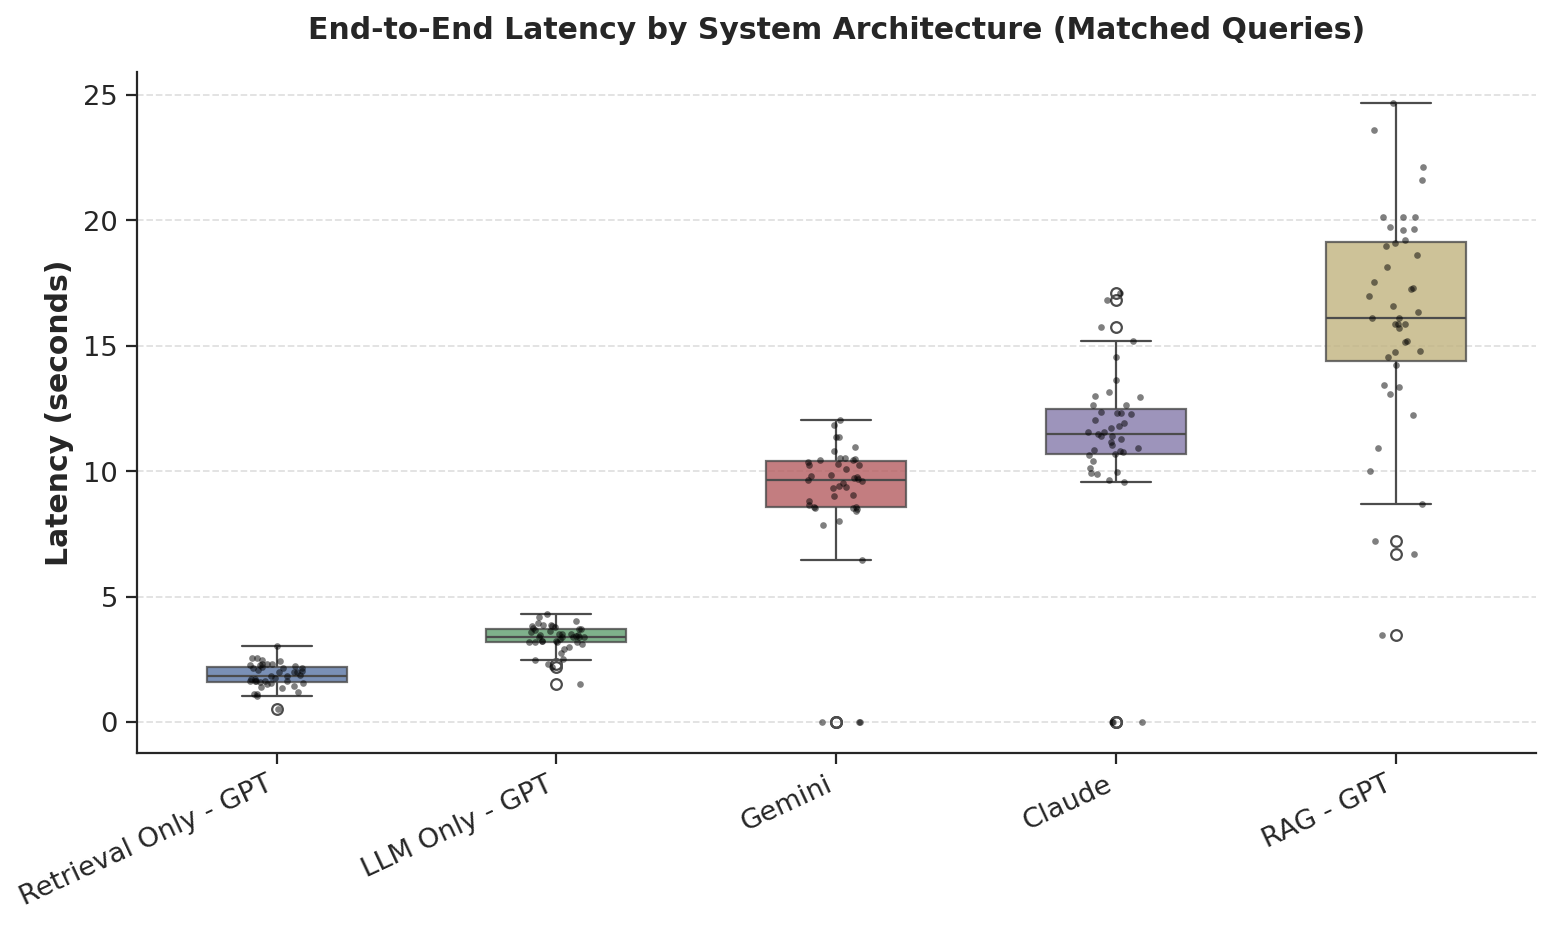

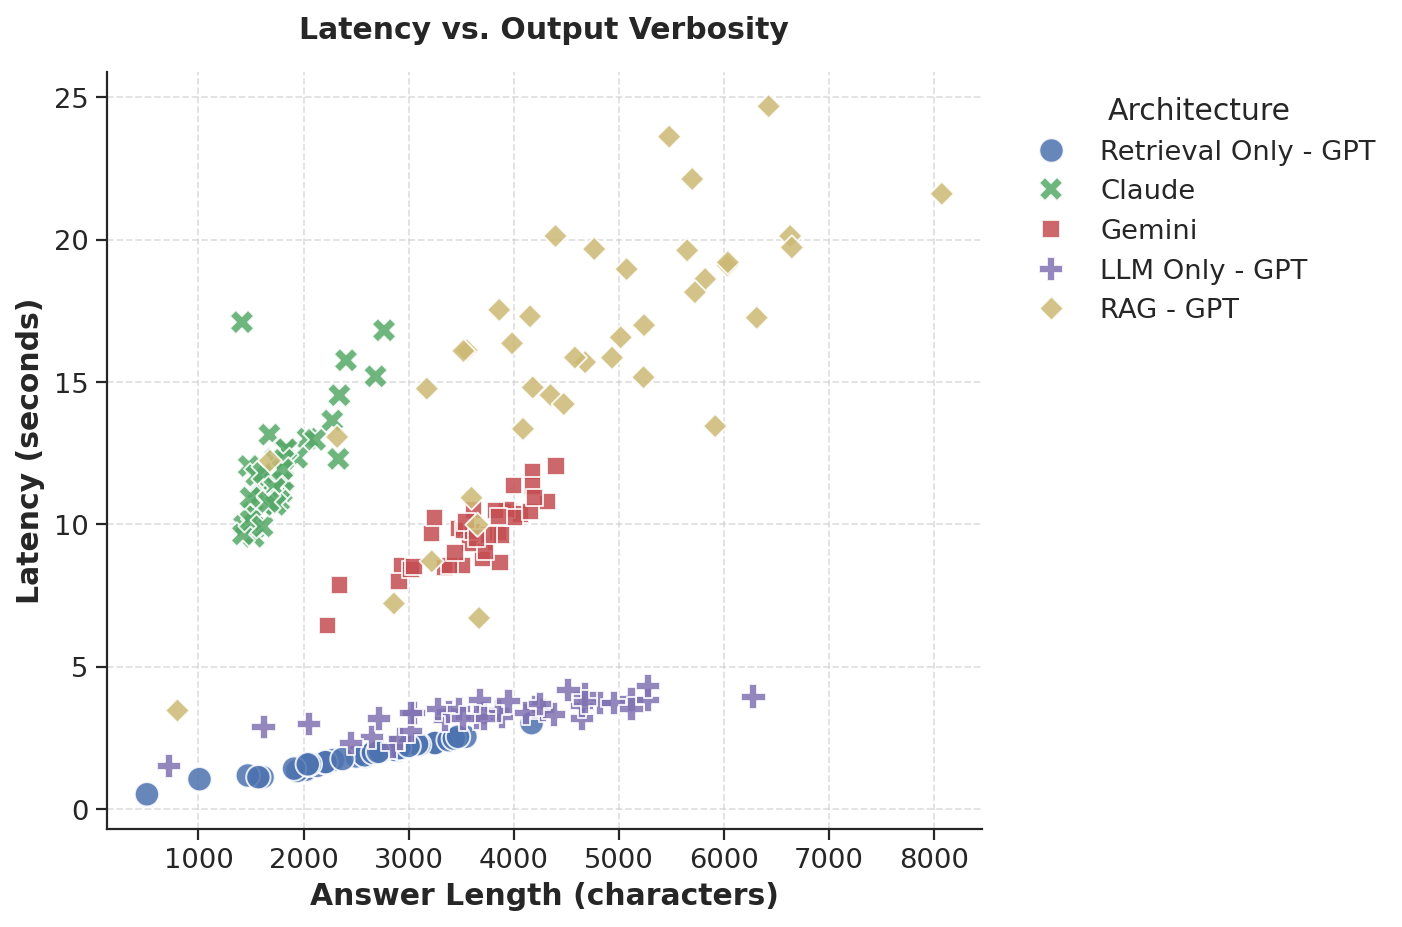

/tmp/ipython-input-680/988875010.py:192: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Model', y='Data_KB', data=df_matched, order=model_order,


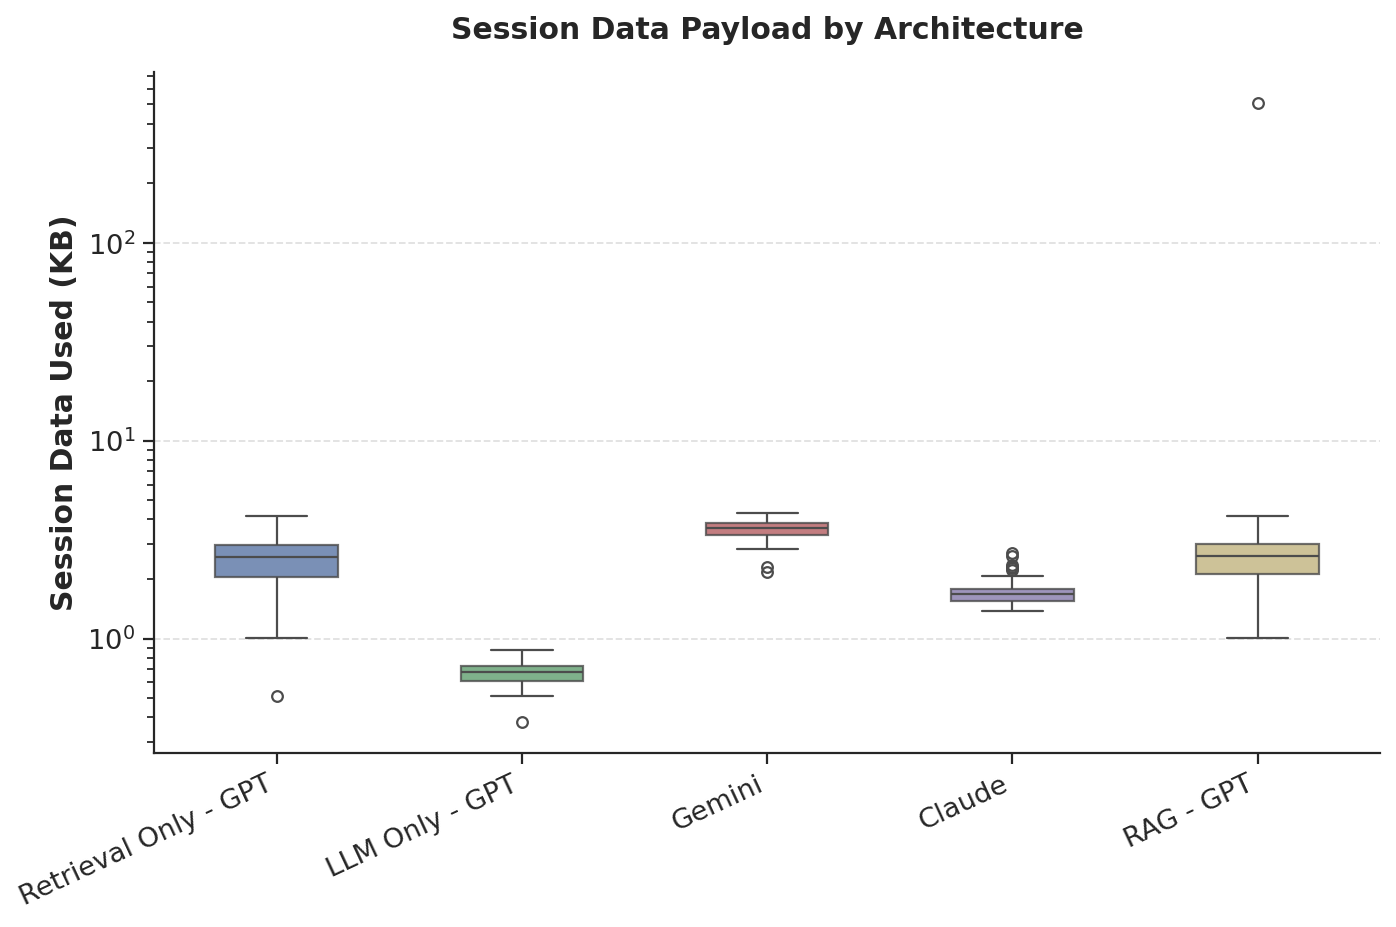

Analysis complete! Tables printed to console, and 3 high-resolution publication-ready PNG files saved.


In [ ]:
# ==============================================================================
# RAG vs. Frontier Models: Performance Benchmarking Script (Excel Version)
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
import re
import os
import glob

# ------------------------------------------------------------------------------
# 1. DYNAMIC EXCEL FILE DETECTION
# ------------------------------------------------------------------------------
print("Scanning Colab directory for uploaded Excel files...")

def find_file(keyword):
    # Searches the current directory for any Excel file containing the keyword
    matches = glob.glob(f"*{keyword}*.xlsx")
    if not matches:
        raise FileNotFoundError(f"Could not find an Excel file containing '{keyword}'. Please ensure it is uploaded.")
    return matches[0]

try:
    file_configs = {
        "Retrieval Only - GPT": {"file": find_file("Retrieval"), "skiprows": 2},
        "Claude": {"file": find_file("Claude"), "skiprows": 1},
        "Gemini": {"file": find_file("Gemini"), "skiprows": 2},
        "LLM Only - GPT": {"file": find_file("LLM only"), "skiprows": 2},
        "RAG - GPT": {"file": find_file("RAG"), "skiprows": 0}
    }
    print("Successfully mapped all 5 Excel files!\n")
except Exception as e:
    print(f"\nERROR: {e}")
    print("Current files in your Colab folder:", os.listdir('.'))
    raise SystemExit("Stopping execution. Please upload the missing file(s).")

# ------------------------------------------------------------------------------
# 2. ROBUST DATA CLEANING FUNCTIONS
# ------------------------------------------------------------------------------
def clean_latency(val):
    if pd.isna(val): return np.nan
    val_str = str(val).lower().replace(',', '')
    match = re.search(r'([\d\.]+)', val_str)
    if not match: return np.nan
    num = float(match.group(1))
    return num / 1000.0 if 'ms' in val_str else num

def clean_data_used(val):
    if pd.isna(val): return np.nan
    val_str = str(val).lower().replace(',', '')
    match = re.search(r'([\d\.]+)', val_str)
    return float(match.group(1)) if match else np.nan

def clean_length(val):
    if pd.isna(val): return np.nan
    val_str = str(val).lower().replace(',', '')
    match = re.search(r'([\d\.]+)', val_str)
    return float(match.group(1)) if match else np.nan

# ------------------------------------------------------------------------------
# 3. DATA LOADING & MERGING
# ------------------------------------------------------------------------------
all_dfs = []
for model_name, config in file_configs.items():
    try:
        # Changed to read_excel to handle the raw .xlsx files
        df = pd.read_excel(config["file"], skiprows=config["skiprows"])
        df = df.iloc[:, :4].copy() # Ensure exactly 4 columns
        df.columns = ["Query", "Latency", "Session_Data_Used", "Answer_Length"]

        # Ensure Query is string and filter out badly parsed rows
        df['Query'] = df['Query'].astype(str)
        df = df[df['Query'].str.len() < 300].copy()

        # Apply strict cleaning
        df['Latency_sec'] = df['Latency'].apply(clean_latency)
        df['Data_KB'] = df['Session_Data_Used'].apply(clean_data_used)
        df['Length_chars'] = df['Answer_Length'].apply(clean_length)
        df['Model'] = model_name

        # Drop rows where Latency failed to parse or is unrealistically high
        df = df.dropna(subset=['Latency_sec'])
        df = df[df['Latency_sec'] < 100]

        all_dfs.append(df[['Model', 'Query', 'Latency_sec', 'Data_KB', 'Length_chars']])
    except Exception as e:
        print(f"Error processing {model_name}: {e}")

combined_df = pd.concat(all_dfs, ignore_index=True)

# ------------------------------------------------------------------------------
# 4. STRICT QUERY MATCHING (Ensuring Apples-to-Apples Comparison)
# ------------------------------------------------------------------------------
# Standardize queries to find perfect matches across all 5 architectures
combined_df['Clean_Query'] = combined_df['Query'].str.lower().str.strip()
query_counts = combined_df.groupby('Clean_Query')['Model'].nunique()

# Only keep queries that were successfully parsed in ALL 5 models
matched_queries = query_counts[query_counts == 5].index
df_matched = combined_df[combined_df['Clean_Query'].isin(matched_queries)].copy()

print(f"Successfully matched {len(matched_queries)} overlapping queries across all 5 models.\n")

# Compute Throughput Metric
df_matched['Latency_per_1k_chars'] = (df_matched['Latency_sec'] / df_matched['Length_chars']) * 1000

# ------------------------------------------------------------------------------
# 5. TABLES: SYSTEM RELIABILITY AND THROUGHPUT METRICS
# ------------------------------------------------------------------------------
def calc_metrics(x):
    return pd.Series({
        'Median Latency (s)': x['Latency_sec'].median(),
        'P90 Latency (s)': x['Latency_sec'].quantile(0.90),
        'P95 Latency (s)': x['Latency_sec'].quantile(0.95),
        'Median Answer Length': x['Length_chars'].median(),
        'Latency per 1k Chars (s)': x['Latency_per_1k_chars'].median(),
        'Median Data Used (KB)': x['Data_KB'].median()
    })

metrics_table = df_matched.groupby('Model').apply(calc_metrics).round(2)
print("=== TABLE 1: MATCHED QUERY PERFORMANCE METRICS ===")
print(metrics_table.to_markdown())
print("\n")
metrics_table.to_csv("Matched_Metrics_Table.csv")

# ------------------------------------------------------------------------------
# 6. REGRESSION ANALYSIS: NON-GENERATION OVERHEAD
# ------------------------------------------------------------------------------
# Filter out Retrieval/RAG to compare pure reasoning overhead in LLM-Only architectures
llm_only_df = df_matched[df_matched['Model'].isin(['LLM Only - GPT', 'Claude', 'Gemini'])].copy()

# Log-transform variables to normalize distributions for OLS
llm_only_df['Log_Latency'] = np.log(llm_only_df['Latency_sec'])
llm_only_df['Log_Chars'] = np.log(llm_only_df['Length_chars'])

# OLS Regression: log(latency) ~ log(chars) + model
# Reference baseline is 'LLM Only - GPT'
reg_model = smf.ols("Log_Latency ~ Log_Chars + C(Model, Treatment(reference='LLM Only - GPT'))", data=llm_only_df).fit()

print("=== TABLE 2: OLS REGRESSION (Log Latency ~ Log Chars + Model) ===")
print(reg_model.summary())
print("\n")
with open('OLS_Regression_Summary.txt', 'w') as f:
    f.write(reg_model.summary().as_text())

# ------------------------------------------------------------------------------
# 7. HIGH-RESOLUTION VISUALIZATIONS (Nature Formatting Standards)
# ------------------------------------------------------------------------------
# Set clean, academic aesthetics suitable for high-impact journals
sns.set_theme(style="ticks", context="paper", font_scale=1.4)
color_palette = ["#4C72B0", "#55A868", "#C44E52", "#8172B2", "#CCB974"]

# Reorder models for logical reading (Fastest to Slowest baseline)
model_order = ['Retrieval Only - GPT', 'LLM Only - GPT', 'Gemini', 'Claude', 'RAG - GPT']

# ---- Plot 1: Latency Distributions (Violin Plot + Boxplot hybrid) ----
plt.figure(figsize=(10, 6))
sns.boxplot(x='Model', y='Latency_sec', data=df_matched, order=model_order,
            palette=color_palette, width=0.5, boxprops=dict(alpha=0.8))
sns.stripplot(x='Model', y='Latency_sec', data=df_matched, order=model_order,
              color="black", size=3, alpha=0.5, jitter=True)
plt.title('End-to-End Latency by System Architecture (Matched Queries)', fontweight='bold', pad=15)
plt.ylabel('Latency (seconds)', fontweight='bold')
plt.xlabel('')
plt.xticks(rotation=25, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
sns.despine()
plt.tight_layout()
plt.savefig('Fig1_Latency_Distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# ---- Plot 2: Latency vs. Answer Length Scatter ----
plt.figure(figsize=(9, 6))
sns.scatterplot(x='Length_chars', y='Latency_sec', hue='Model', style='Model',
                data=df_matched, s=120, alpha=0.85, palette=color_palette)
plt.title('Latency vs. Output Verbosity', fontweight='bold', pad=15)
plt.ylabel('Latency (seconds)', fontweight='bold')
plt.xlabel('Answer Length (characters)', fontweight='bold')
plt.legend(title='Architecture', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
plt.grid(True, linestyle='--', alpha=0.6)
sns.despine()
plt.tight_layout()
plt.savefig('Fig2_Latency_vs_Length.png', dpi=300, bbox_inches='tight')
plt.show()

# ---- Plot 3: Session Data Payload (Bandwidth Overhead) ----
plt.figure(figsize=(9, 6))
# Using a log scale for Y-axis if data payload spans multiple magnitudes
sns.boxplot(x='Model', y='Data_KB', data=df_matched, order=model_order,
            palette=color_palette, width=0.5, boxprops=dict(alpha=0.8))
plt.title('Session Data Payload by Architecture', fontweight='bold', pad=15)
plt.ylabel('Session Data Used (KB)', fontweight='bold')
plt.xlabel('')
plt.yscale('log') # Log scale handles the difference between GPT's 0.6KB and RAG's heavy outliers
plt.xticks(rotation=25, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
sns.despine()
plt.tight_layout()
plt.savefig('Fig3_Data_Payload_LogScale.png', dpi=300, bbox_inches='tight')
plt.show()

print("Analysis complete! Tables printed to console, and 3 high-resolution publication-ready PNG files saved.")

In [ ]:
# ============================================================
# PATCH v2: FIX np.isfinite TypeError (still object somewhere)
# ============================================================
# This version is brutally explicit:
# - converts X and y to numpy float arrays using np.asarray(..., dtype=float)
# - rows that can't be converted become NaN (via pandas to_numeric + astype)
# - then we build the mask using np.isfinite on float arrays only
# ============================================================

import numpy as np
import pandas as pd
import statsmodels.api as sm

reg_df = df_all5.copy()

# Coerce core numeric columns
for col in ["Latency_ms", "Payload_KB", "Answer_chars"]:
    reg_df[col] = pd.to_numeric(reg_df[col], errors="coerce")

reg_df = reg_df[(reg_df["Latency_ms"] > 0) & (reg_df["Payload_KB"] > 0) & (reg_df["Answer_chars"] > 0)].copy()
reg_df["log_latency"] = np.log(reg_df["Latency_ms"])
reg_df["log_kb"] = np.log(reg_df["Payload_KB"])
reg_df["log_chars"] = np.log(reg_df["Answer_chars"])

# Dummies (ensure System is string)
reg_df["System"] = reg_df["System"].astype(str)
X_df = pd.get_dummies(reg_df[["log_kb", "log_chars", "System"]], columns=["System"], drop_first=True)

# Force every column numeric; if it can't be numeric, becomes NaN
for c in X_df.columns:
    X_df[c] = pd.to_numeric(X_df[c], errors="coerce")

# Add intercept
X_df.insert(0, "const", 1.0)

# y numeric
y_s = pd.to_numeric(reg_df["log_latency"], errors="coerce")

# Convert to float numpy arrays (this prevents the isfinite TypeError)
X = np.asarray(X_df.values, dtype=float)
y = np.asarray(y_s.values, dtype=float)

# Finite mask (now guaranteed float)
mask = np.isfinite(y) & np.isfinite(X).all(axis=1)
X = X[mask]
y = y[mask]

# Fit robust OLS
ols = sm.OLS(y, X).fit(cov_type="HC3")

# Rebuild labeled regression table
colnames = list(X_df.columns)
params = pd.Series(ols.params, index=colnames, name="coef")
ses = pd.Series(ols.bse, index=colnames, name="robust_se")
tvals = pd.Series(ols.tvalues, index=colnames, name="t")
pvals = pd.Series(ols.pvalues, index=colnames, name="p")

reg_table = pd.concat([params, ses, tvals, pvals], axis=1).sort_values("p")

reg_summary_text = (
    f"OLS with HC3 robust SEs\n"
    f"N={int(ols.nobs)} | R^2={ols.rsquared:.3f} | Adj.R^2={ols.rsquared_adj:.3f}\n"
    f"Model: log(latency) ~ log(chars) + log(KB) + system dummies\n\n"
    + reg_table.to_string(float_format=lambda x: f"{x: .4f}")
)

print(reg_summary_text)

OLS with HC3 robust SEs
N=200 | R^2=0.998 | Adj.R^2=0.998
Model: log(latency) ~ log(chars) + log(KB) + system dummies

                               coef  robust_se        t       p
System_Retrieval Only - GPT  4.8170     0.0680  70.8579  0.0000
System_RAG Stats - GPT       6.5618     0.2912  22.5373  0.0000
System_Gemini Responses     -0.6651     0.1147  -5.7967  0.0000
System_LLM only query - GPT  5.1130     1.0894   4.6934  0.0000
log_chars                    0.6737     0.5710   1.1800  0.2380
const                       -2.5456     3.8803  -0.6560  0.5118
log_kb                      -0.0337     0.7162  -0.0471  0.9624


In [ ]:
import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.api as sm
import matplotlib.pyplot as plt
from pathlib import Path

OUT_DIR = Path("/content/analysis_outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

systems_all = ["LLM only query - GPT","RAG Stats - GPT","Retrieval Only - GPT","Claude Responses","Gemini Responses"]

# ----------------------------
# 1) Publication-grade helpers
# ----------------------------
def save_fig(fig, name):
    fig.tight_layout()
    fig.savefig(OUT_DIR / f"{name}.png", bbox_inches="tight")
    fig.savefig(OUT_DIR / f"{name}.pdf", bbox_inches="tight")
    plt.close(fig)

def pct(x, p):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    return np.nanpercentile(x, p) if len(x) else np.nan

def describe_group(d):
    rows = []
    for sys, sub in d.groupby("System"):
        lat = sub["Latency_ms"].to_numpy(float)
        kb  = sub["Payload_KB"].to_numpy(float)
        ch  = sub["Answer_chars"].to_numpy(float)
        rows.append({
            "System": sys,
            "N": sub["Query_key"].nunique(),
            "Latency_mean_ms": np.nanmean(lat),
            "Latency_median_ms": np.nanmedian(lat),
            "Latency_P90_ms": pct(lat, 90),
            "Latency_P95_ms": pct(lat, 95),
            "Latency_P99_ms": pct(lat, 99),
            "Latency_max_ms": np.nanmax(lat),
            "Payload_median_KB": np.nanmedian(kb),
            "Payload_P95_KB": pct(kb, 95),
            "Chars_median": np.nanmedian(ch),
            "Chars_P95": pct(ch, 95),
        })
    return pd.DataFrame(rows).sort_values("Latency_median_ms")

def add_normalized(d):
    out = d.copy()
    out["ms_per_KB"] = out["Latency_ms"] / out["Payload_KB"].replace(0, np.nan)
    out["ms_per_1k_chars"] = out["Latency_ms"] / (out["Answer_chars"].replace(0, np.nan) / 1000.0)
    return out

def threshold_table(d, t1=1000, t2=10000):
    rows = []
    for sys, sub in d.groupby("System"):
        lat = sub["Latency_ms"].to_numpy(float)
        rows.append({
            "System": sys,
            "N": sub["Query_key"].nunique(),
            "pct_under_1s": float(np.mean(lat < t1) * 100),
            "pct_under_10s": float(np.mean(lat < t2) * 100),
            "pct_over_10s": float(np.mean(lat >= t2) * 100),
        })
    return pd.DataFrame(rows).sort_values("pct_under_10s", ascending=False)

def paired_bootstrap_ci(d, sys_a, sys_b, metric="Latency_ms", n_boot=30000, seed=7):
    rng = np.random.default_rng(seed)
    piv = d.pivot_table(index="Query_key", columns="System", values=metric, aggfunc="first")
    piv = piv[[sys_a, sys_b]].dropna()
    a = piv[sys_a].to_numpy(float)
    b = piv[sys_b].to_numpy(float)

    diffs = a - b
    n = len(diffs)
    idx = rng.integers(0, n, size=(n_boot, n))
    boot_mean = np.mean(diffs[idx], axis=1)
    boot_med  = np.median(diffs[idx], axis=1)

    out = {
        "A": sys_a, "B": sys_b, "metric": metric, "N_pairs": n,
        "mean_diff": float(np.mean(diffs)),
        "mean_CI_low": float(np.percentile(boot_mean, 2.5)),
        "mean_CI_high": float(np.percentile(boot_mean, 97.5)),
        "median_diff": float(np.median(diffs)),
        "median_CI_low": float(np.percentile(boot_med, 2.5)),
        "median_CI_high": float(np.percentile(boot_med, 97.5)),
        "geo_ratio": np.nan,
        "geo_CI_low": np.nan,
        "geo_CI_high": np.nan
    }

    # Ratio (geometric mean) on log scale if positive
    if np.all(a > 0) and np.all(b > 0):
        lr = np.log(a / b)
        boot_lr = np.mean(lr[idx], axis=1)
        out["geo_ratio"] = float(np.exp(np.mean(lr)))
        out["geo_CI_low"] = float(np.exp(np.percentile(boot_lr, 2.5)))
        out["geo_CI_high"] = float(np.exp(np.percentile(boot_lr, 97.5)))
    return out

# --------------------------------
# 2) Core tables (all-5 matched)
# --------------------------------
desc_all5 = describe_group(df_all5)
ux_all5   = threshold_table(df_all5)
df_all5_n = add_normalized(df_all5)

norm_all5 = (
    df_all5_n.groupby("System")
    .agg(
        N=("Query_key","nunique"),
        ms_per_1k_chars_median=("ms_per_1k_chars","median"),
        ms_per_1k_chars_P95=("ms_per_1k_chars", lambda x: np.nanpercentile(x.dropna(),95) if len(x.dropna()) else np.nan),
        ms_per_KB_median=("ms_per_KB","median"),
        ms_per_KB_P95=("ms_per_KB", lambda x: np.nanpercentile(x.dropna(),95) if len(x.dropna()) else np.nan),
    ).reset_index()
    .sort_values("ms_per_1k_chars_median")
)

# --------------------------------
# 3) Paired bootstrap comparisons
# --------------------------------
boot_rows = []
# GPT architecture (matched)
boot_rows += [
    paired_bootstrap_ci(df_gpt_arch, "RAG Stats - GPT", "LLM only query - GPT"),
    paired_bootstrap_ci(df_gpt_arch, "RAG Stats - GPT", "Retrieval Only - GPT"),
    paired_bootstrap_ci(df_gpt_arch, "LLM only query - GPT", "Retrieval Only - GPT"),
]
# LLM-only models (matched)
boot_rows += [
    paired_bootstrap_ci(df_llm_only, "Claude Responses", "Gemini Responses"),
    paired_bootstrap_ci(df_llm_only, "Claude Responses", "LLM only query - GPT"),
    paired_bootstrap_ci(df_llm_only, "Gemini Responses", "LLM only query - GPT"),
]
boot_df = pd.DataFrame(boot_rows)

# --------------------------------
# 4) Per-query difficulty + rank agreement (all-5 matched)
# --------------------------------
query_lat = df_all5.pivot_table(index="Query_key", columns="System", values="Latency_ms", aggfunc="median")
query_lat["median_across_systems"] = query_lat.median(axis=1, skipna=True)
hardest = query_lat.sort_values("median_across_systems", ascending=False).head(15).reset_index()

query_rank = query_lat[systems_all].rank(axis=0, method="average")
rank_agree = []
for i in range(len(systems_all)):
    for j in range(i+1, len(systems_all)):
        a, b = systems_all[i], systems_all[j]
        v = query_rank[[a,b]].dropna()
        if len(v) >= 10:
            r = stats.spearmanr(v[a], v[b])
            rank_agree.append({"System_A": a, "System_B": b, "Spearman_rank_r": r.correlation, "p": r.pvalue, "N_queries": len(v)})
rank_agree_df = pd.DataFrame(rank_agree).sort_values("Spearman_rank_r", ascending=False)

# --------------------------------
# 5) Regressions (SEPARATE, safer)
# --------------------------------
def run_regression(d, label):
    d = d.copy()
    for col in ["Latency_ms","Payload_KB","Answer_chars"]:
        d[col] = pd.to_numeric(d[col], errors="coerce")
    d = d[(d["Latency_ms"]>0) & (d["Payload_KB"]>0) & (d["Answer_chars"]>0)].copy()

    d["log_latency"] = np.log(d["Latency_ms"])
    d["log_kb"]      = np.log(d["Payload_KB"])
    d["log_chars"]   = np.log(d["Answer_chars"])
    d["System"]      = d["System"].astype(str)

    X_df = pd.get_dummies(d[["log_kb","log_chars","System"]], columns=["System"], drop_first=True)
    for c in X_df.columns:
        X_df[c] = pd.to_numeric(X_df[c], errors="coerce")
    X_df.insert(0, "const", 1.0)

    y = pd.to_numeric(d["log_latency"], errors="coerce")

    X = np.asarray(X_df.values, dtype=float)
    y = np.asarray(y.values, dtype=float)
    mask = np.isfinite(y) & np.isfinite(X).all(axis=1)
    X, y = X[mask], y[mask]

    ols = sm.OLS(y, X).fit(cov_type="HC3")

    cols = list(X_df.columns)
    reg_table = pd.DataFrame({
        "coef": ols.params,
        "robust_se": ols.bse,
        "t": ols.tvalues,
        "p": ols.pvalues
    }, index=cols).sort_values("p")

    summary = {
        "label": label,
        "N": int(ols.nobs),
        "R2": float(ols.rsquared),
        "Adj_R2": float(ols.rsquared_adj),
    }
    return summary, reg_table

reg1_summary, reg1_table = run_regression(df_llm_only, "LLM-only only (GPT vs Claude vs Gemini)")
reg2_summary, reg2_table = run_regression(df_gpt_arch, "GPT-only architecture (Retrieval vs LLM-only vs RAG)")

# --------------------------------
# 6) Figures (world-class defaults)
# --------------------------------
# (A) Latency boxplot (all-5 matched)
fig, ax = plt.subplots()
ax.boxplot([df_all5[df_all5["System"]==s]["Latency_ms"].dropna().values for s in systems_all],
           labels=systems_all, showfliers=True)
ax.set_title("Latency Distribution by System (Matched All-5 Query Set)")
ax.set_ylabel("Latency (ms)")
ax.tick_params(axis="x", rotation=25)
save_fig(fig, "fig_latency_boxplot_all5")

# (B) P95 tail latency bar chart
tail = desc_all5.set_index("System").reindex(systems_all)
fig, ax = plt.subplots()
ax.bar(tail.index, tail["Latency_P95_ms"])
ax.set_title("Tail Latency (P95) by System (Matched All-5 Query Set)")
ax.set_ylabel("P95 Latency (ms)")
ax.tick_params(axis="x", rotation=25)
save_fig(fig, "fig_latency_p95_bar")

# (C) Latency vs chars (log-log) with trend per system
fig, ax = plt.subplots()
for s in systems_all:
    sub = df_all5[df_all5["System"]==s].dropna(subset=["Latency_ms","Answer_chars"])
    ax.scatter(sub["Answer_chars"], sub["Latency_ms"], alpha=0.65, label=s)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Latency vs Answer Length (log-log) (Matched All-5 Query Set)")
ax.set_xlabel("Answer length (chars, log)")
ax.set_ylabel("Latency (ms, log)")
ax.legend()
save_fig(fig, "fig_latency_vs_chars_loglog")

# (D) UX: % under 10s
fig, ax = plt.subplots()
ux_plot = ux_all5.set_index("System").reindex(systems_all)
ax.bar(ux_plot.index, ux_plot["pct_under_10s"])
ax.set_title("Percent of Queries Under 10 Seconds (Matched All-5 Query Set)")
ax.set_ylabel("% under 10s")
ax.tick_params(axis="x", rotation=25)
save_fig(fig, "fig_pct_under_10s")

# --------------------------------
# 7) Export report + Excel
# --------------------------------
def fmt_numeric(df_in, digits=3):
    df2 = df_in.copy()
    for c in df2.columns:
        if pd.api.types.is_numeric_dtype(df2[c]):
            df2[c] = df2[c].map(lambda x: "" if pd.isna(x) else f"{x:,.{digits}f}")
    return df2

report_lines = []
report_lines.append("# Benchmark Analysis Report (Auto-generated)\n")

report_lines.append("## Descriptive stats (All-5 matched)\n")
report_lines.append(fmt_numeric(desc_all5).to_markdown(index=False) + "\n\n")

report_lines.append("## Normalized latency (All-5 matched)\n")
report_lines.append(fmt_numeric(norm_all5).to_markdown(index=False) + "\n\n")

report_lines.append("## UX thresholds (All-5 matched)\n")
report_lines.append(fmt_numeric(ux_all5, digits=2).to_markdown(index=False) + "\n\n")

report_lines.append("## Paired bootstrap comparisons (Latency, matched queries)\n")
report_lines.append(fmt_numeric(boot_df).to_markdown(index=False) + "\n\n")

report_lines.append("## Hardest queries (highest median latency across systems)\n")
report_lines.append(hardest[["Query_key","median_across_systems"]].rename(columns={"Query_key":"Query"}).to_markdown(index=False) + "\n\n")

report_lines.append("## Rank agreement between systems (Spearman)\n")
report_lines.append(fmt_numeric(rank_agree_df, digits=4).to_markdown(index=False) + "\n\n")

report_lines.append("## Regression R1 (LLM-only only)\n")
report_lines.append(f"- N={reg1_summary['N']}, R²={reg1_summary['R2']:.3f}, Adj.R²={reg1_summary['Adj_R2']:.3f}\n\n")
report_lines.append(fmt_numeric(reg1_table, digits=4).to_markdown() + "\n\n")

report_lines.append("## Regression R2 (GPT-only architecture)\n")
report_lines.append(f"- N={reg2_summary['N']}, R²={reg2_summary['R2']:.3f}, Adj.R²={reg2_summary['Adj_R2']:.3f}\n\n")
report_lines.append(fmt_numeric(reg2_table, digits=4).to_markdown() + "\n\n")

report_path = OUT_DIR / "analysis_report.md"
report_path.write_text("\n".join(report_lines), encoding="utf-8")

excel_path = OUT_DIR / "benchmark_analysis_outputs.xlsx"
with pd.ExcelWriter(excel_path, engine="xlsxwriter") as w:
    df_all5.to_excel(w, sheet_name="all5_matched_raw", index=False)
    desc_all5.to_excel(w, sheet_name="desc_all5", index=False)
    norm_all5.to_excel(w, sheet_name="normalized_all5", index=False)
    ux_all5.to_excel(w, sheet_name="ux_all5", index=False)
    boot_df.to_excel(w, sheet_name="paired_bootstrap", index=False)
    hardest.to_excel(w, sheet_name="hardest_queries", index=False)
    rank_agree_df.to_excel(w, sheet_name="rank_agreement", index=False)
    reg1_table.reset_index().rename(columns={"index":"term"}).to_excel(w, sheet_name="reg_llm_only", index=False)
    reg2_table.reset_index().rename(columns={"index":"term"}).to_excel(w, sheet_name="reg_gpt_arch", index=False)

print("✅ Saved figures + tables to:", OUT_DIR)
print("✅ Report:", report_path)
print("✅ Excel:", excel_path)

/tmp/ipython-input-680/1070152454.py:210: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([df_all5[df_all5["System"]==s]["Latency_ms"].dropna().values for s in systems_all],


✅ Saved figures + tables to: /content/analysis_outputs
✅ Report: /content/analysis_outputs/analysis_report.md
✅ Excel: /content/analysis_outputs/benchmark_analysis_outputs.xlsx


=== TABLE 1: UX THRESHOLD EXCEEDANCE (%) ===
UX_Category           Optimal (< 1s)  Acceptable (1 - 10s)  Abandonment Risk (> 10s)
Model                                                                               
Retrieval Only - GPT             2.3                  97.7                       0.0
LLM Only - GPT                   0.0                 100.0                       0.0
Gemini                           7.0                  55.8                      37.2
Claude                           7.0                  11.6                      81.4
RAG - GPT                        0.0                  11.6                      88.4




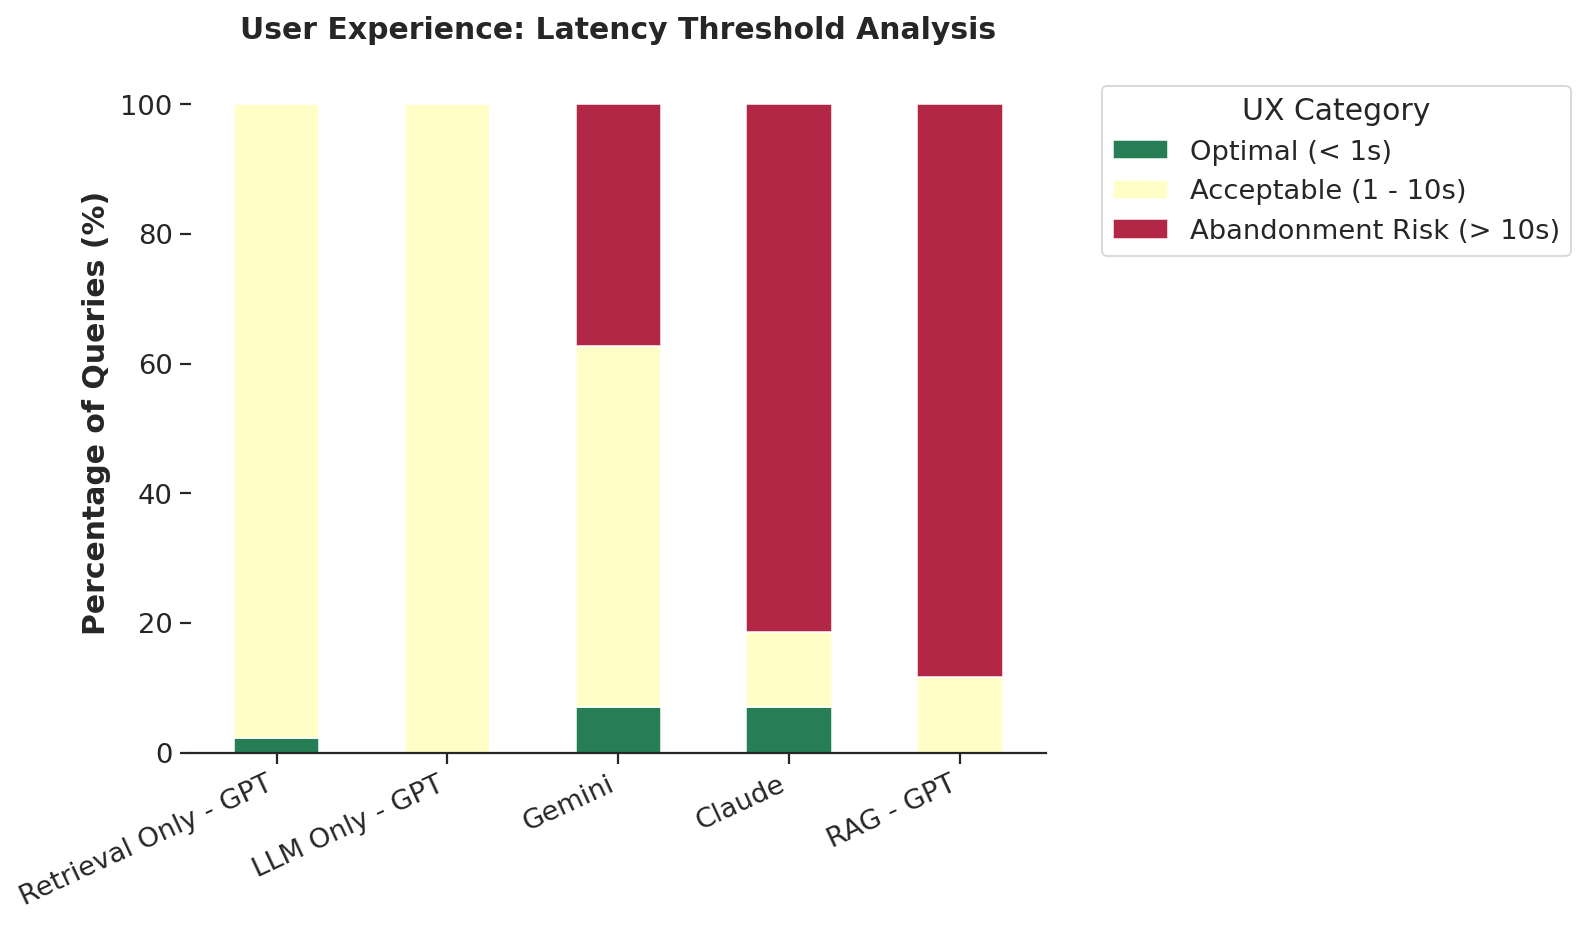

=== TABLE 2: PAIRED BOOTSTRAP EFFECT SIZES (Ref: LLM Only - GPT) ===
Retrieval Only - GPT vs LLM Only - GPT:
  Median Latency Difference: +-1.50s (95% CI: [-1.60s, -1.40s])
  Latency Multiplier: 0.55x (95% CI: [0.52x, 0.59x])

Gemini vs LLM Only - GPT:
  Median Latency Difference: +6.27s (95% CI: [5.91s, 6.52s])
  Latency Multiplier: 2.78x (95% CI: [2.71x, 3.02x])

Claude vs LLM Only - GPT:
  Median Latency Difference: +8.19s (95% CI: [7.82s, 8.62s])
  Latency Multiplier: 3.44x (95% CI: [3.32x, 3.69x])

RAG - GPT vs LLM Only - GPT:
  Median Latency Difference: +12.74s (95% CI: [11.92s, 14.02s])
  Latency Multiplier: 4.77x (95% CI: [4.66x, 5.02x])

=== TABLE 3: ELASTICITY REGRESSION (Log-Log) ===
Measures how scaling payload/verbosity impacts latency overhead across architectures.
                                                                              coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------

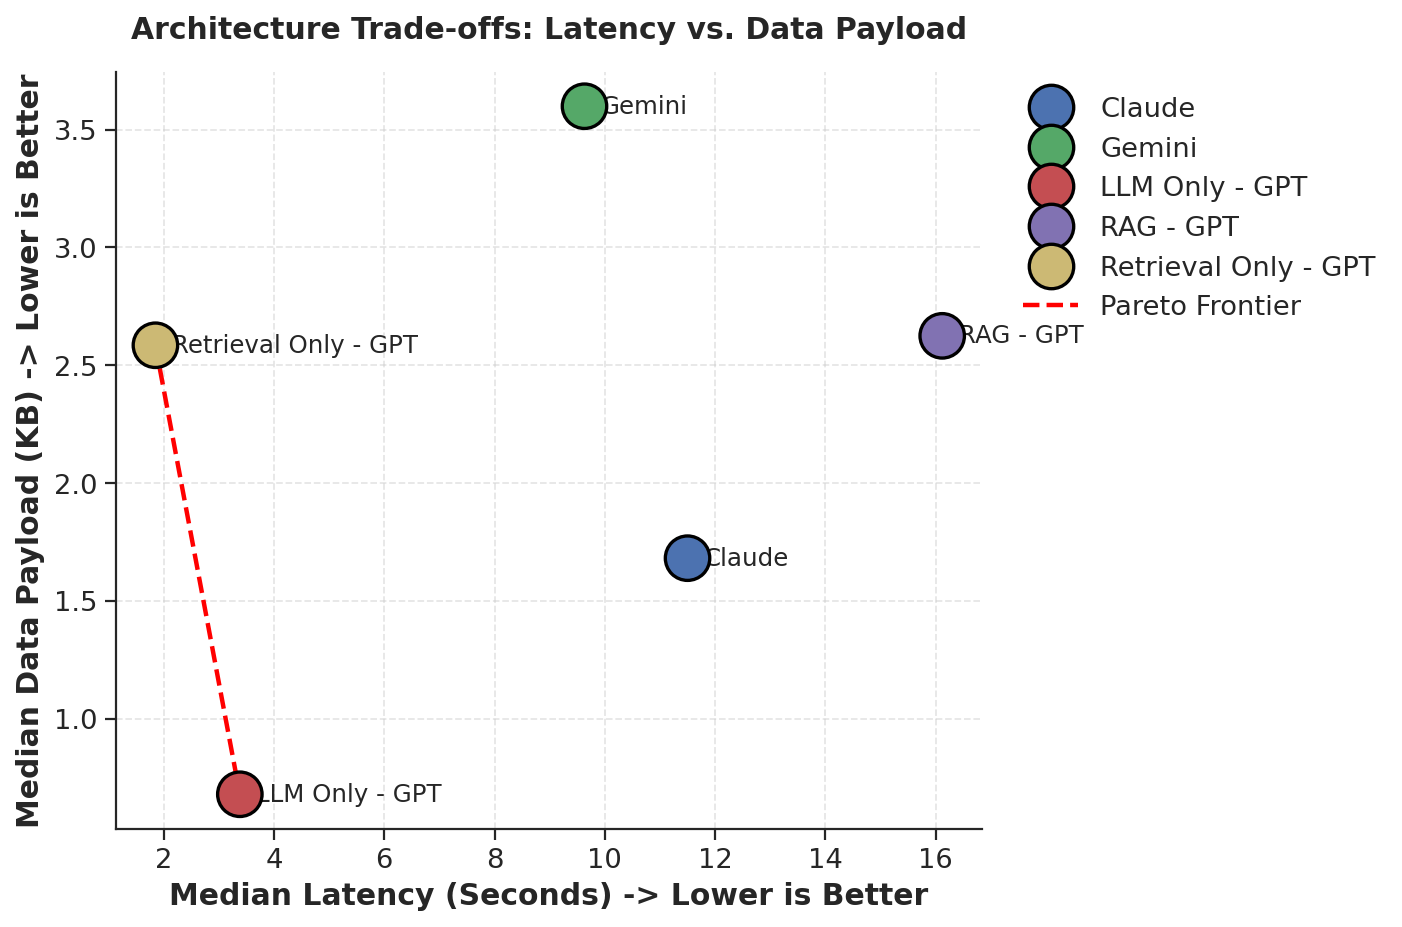

Analysis complete! Data saved and ready for integration into the manuscript.


In [ ]:
# ==============================================================================
# RAG vs. Frontier Models: Deployment Constraints & UX Analysis (Excel Version)
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
import re
import glob

# Set visual style for high-impact journals
sns.set_theme(style="ticks", context="paper", font_scale=1.4)
color_palette = ["#4C72B0", "#55A868", "#C44E52", "#8172B2", "#CCB974"]
model_order = ['Retrieval Only - GPT', 'LLM Only - GPT', 'Gemini', 'Claude', 'RAG - GPT']

# ------------------------------------------------------------------------------
# 1. LOAD & CLEAN DATA (Using established perfectly-matched logic)
# ------------------------------------------------------------------------------
def clean_latency(val):
    if pd.isna(val): return np.nan
    val_str = str(val).lower().replace(',', '')
    match = re.search(r'([\d\.]+)', val_str)
    return (float(match.group(1)) / 1000.0) if match and 'ms' in val_str else (float(match.group(1)) if match else np.nan)

def clean_data_used(val):
    if pd.isna(val): return np.nan
    val_str = str(val).lower().replace(',', '')
    match = re.search(r'([\d\.]+)', val_str)
    return float(match.group(1)) if match else np.nan

all_dfs = []
for keyword, model_name, skiprows in [
    ("Retrieval", "Retrieval Only - GPT", 2), ("Claude", "Claude", 1),
    ("Gemini", "Gemini", 2), ("LLM only", "LLM Only - GPT", 2), ("RAG", "RAG - GPT", 0)]:
    try:
        file_path = glob.glob(f"*{keyword}*.xlsx")[0]
        df = pd.read_excel(file_path, skiprows=skiprows).iloc[:, :4]
        df.columns = ["Query", "Latency", "Session_Data_Used", "Answer_Length"]
        df['Query'] = df['Query'].astype(str)
        df = df[df['Query'].str.len() < 300].copy()
        df['Latency_sec'] = df['Latency'].apply(clean_latency)
        df['Data_KB'] = df['Session_Data_Used'].apply(clean_data_used)
        df['Length_chars'] = df['Answer_Length'].apply(clean_data_used) # Reusing number extractor
        df['Model'] = model_name
        df = df.dropna(subset=['Latency_sec'])
        all_dfs.append(df[df['Latency_sec'] < 100])
    except Exception as e:
        print(f"Error loading {model_name}: {e}")

combined_df = pd.concat(all_dfs, ignore_index=True)
combined_df['Clean_Query'] = combined_df['Query'].str.lower().str.strip()
matched_queries = combined_df.groupby('Clean_Query')['Model'].nunique()[lambda x: x == 5].index
df_matched = combined_df[combined_df['Clean_Query'].isin(matched_queries)].copy()

# ------------------------------------------------------------------------------
# 2. UX THRESHOLD EXCEEDANCE (Abandonment Risk Analysis)
# ------------------------------------------------------------------------------
def categorize_ux(latency):
    if latency < 1.0: return "Optimal (< 1s)"
    elif latency <= 10.0: return "Acceptable (1 - 10s)"
    else: return "Abandonment Risk (> 10s)"

df_matched['UX_Category'] = df_matched['Latency_sec'].apply(categorize_ux)

# Calculate percentages
ux_counts = df_matched.groupby(['Model', 'UX_Category']).size().unstack(fill_value=0)
ux_percentages = ux_counts.div(ux_counts.sum(axis=1), axis=0) * 100

# Reorder columns and rows for plotting
ux_cols = ["Optimal (< 1s)", "Acceptable (1 - 10s)", "Abandonment Risk (> 10s)"]
ux_percentages = ux_percentages.reindex(columns=[c for c in ux_cols if c in ux_percentages.columns], index=model_order)

print("=== TABLE 1: UX THRESHOLD EXCEEDANCE (%) ===")
print(ux_percentages.round(1).to_string())
print("\n")

# Plot UX Thresholds
ax = ux_percentages.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='RdYlGn_r', alpha=0.85)
plt.title('User Experience: Latency Threshold Analysis', fontweight='bold', pad=15)
plt.ylabel('Percentage of Queries (%)', fontweight='bold')
plt.xlabel('')
plt.xticks(rotation=25, ha='right')
plt.legend(title='UX Category', bbox_to_anchor=(1.05, 1), loc='upper left')
sns.despine(top=True, right=True, left=True)
plt.tight_layout()
plt.savefig('Fig4_UX_Abandonment_Risk.png', dpi=300, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------------------------
# 3. PAIRED BOOTSTRAP CONFIDENCE INTERVALS (Effect Sizes)
# ------------------------------------------------------------------------------
print("=== TABLE 2: PAIRED BOOTSTRAP EFFECT SIZES (Ref: LLM Only - GPT) ===")
# Pivot to have one row per query, columns as models
df_pivot = df_matched.pivot(index='Clean_Query', columns='Model', values='Latency_sec')
baseline = 'LLM Only - GPT'
comparisons = ['Retrieval Only - GPT', 'Gemini', 'Claude', 'RAG - GPT']

np.random.seed(42)
n_bootstraps = 10000

for comp in comparisons:
    diffs = (df_pivot[comp] - df_pivot[baseline]).dropna().values

    # Bootstrap median differences
    boot_diffs = np.random.choice(diffs, size=(n_bootstraps, len(diffs)), replace=True)
    boot_medians = np.median(boot_diffs, axis=1)

    med_diff = np.median(diffs)
    ci_lower, ci_upper = np.percentile(boot_medians, 2.5), np.percentile(boot_medians, 97.5)

    # Bootstrap ratio (multiplicative overhead)
    ratios = (df_pivot[comp] / df_pivot[baseline]).dropna().values
    boot_ratios = np.random.choice(ratios, size=(n_bootstraps, len(ratios)), replace=True)
    boot_med_ratios = np.median(boot_ratios, axis=1)
    med_ratio = np.median(ratios)
    r_ci_lower, r_ci_upper = np.percentile(boot_med_ratios, 2.5), np.percentile(boot_med_ratios, 97.5)

    print(f"{comp} vs {baseline}:")
    print(f"  Median Latency Difference: +{med_diff:.2f}s (95% CI: [{ci_lower:.2f}s, {ci_upper:.2f}s])")
    print(f"  Latency Multiplier: {med_ratio:.2f}x (95% CI: [{r_ci_lower:.2f}x, {r_ci_upper:.2f}x])\n")

# ------------------------------------------------------------------------------
# 4. LATENCY-PAYLOAD ELASTICITY REGRESSION
# ------------------------------------------------------------------------------
df_matched['Log_Latency'] = np.log(df_matched['Latency_sec'])
df_matched['Log_Chars'] = np.log(df_matched['Length_chars'])
df_matched['Log_KB'] = np.log(df_matched['Data_KB'])

# OLS: log(Latency) ~ log(Chars) + log(KB) + Model
elasticity_model = smf.ols("Log_Latency ~ Log_Chars + Log_KB + C(Model, Treatment(reference='LLM Only - GPT'))", data=df_matched).fit()

print("=== TABLE 3: ELASTICITY REGRESSION (Log-Log) ===")
print("Measures how scaling payload/verbosity impacts latency overhead across architectures.")
print(elasticity_model.summary().tables[1])
print("\n")

# ------------------------------------------------------------------------------
# 5. MULTI-OBJECTIVE PARETO FRONTIER (Speed vs. Bandwidth Trade-off)
# ------------------------------------------------------------------------------
pareto_data = df_matched.groupby('Model').agg({
    'Latency_sec': 'median',
    'Data_KB': 'median'
}).reset_index()

plt.figure(figsize=(9, 6))
sns.scatterplot(x='Latency_sec', y='Data_KB', hue='Model', data=pareto_data,
                s=400, palette=color_palette, edgecolor='black', linewidth=1.5, zorder=5)

# Calculate the Pareto Frontier (minimize Latency, minimize KB)
pareto_data_sorted = pareto_data.sort_values('Latency_sec')
frontier_x, frontier_y = [], []
current_min_y = float('inf')

for _, row in pareto_data_sorted.iterrows():
    if row['Data_KB'] <= current_min_y:
        frontier_x.append(row['Latency_sec'])
        frontier_y.append(row['Data_KB'])
        current_min_y = row['Data_KB']

# Draw the frontier line
plt.plot(frontier_x, frontier_y, color='red', linestyle='--', linewidth=2, zorder=1, label='Pareto Frontier')

plt.title('Architecture Trade-offs: Latency vs. Data Payload', fontweight='bold', pad=15)
plt.xlabel('Median Latency (Seconds) -> Lower is Better', fontweight='bold')
plt.ylabel('Median Data Payload (KB) -> Lower is Better', fontweight='bold')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
plt.grid(True, linestyle='--', alpha=0.5)
sns.despine()

# Annotate points
for _, row in pareto_data.iterrows():
    plt.text(row['Latency_sec'] + 0.3, row['Data_KB'], row['Model'],
             fontsize=11, verticalalignment='center')

plt.tight_layout()
plt.savefig('Fig5_Pareto_Frontier.png', dpi=300, bbox_inches='tight')
plt.show()

print("Analysis complete! Data saved and ready for integration into the manuscript.")